In [1]:
# ============================================================
# セル1: ライブラリのインポートと初期設定
# ============================================================
import pandas as pd
import numpy as np
import ast
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
from torchdiffeq import odeint
from sklearn.metrics import roc_auc_score, average_precision_score
from torch.optim.lr_scheduler import ReduceLROnPlateau
import time
import os
import warnings
import pickle
import json
from datetime import datetime
from collections import defaultdict
import time

warnings.filterwarnings('ignore')

# 再現性のためのシード設定
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


# ============================================================
# セル2: データ前処理関数の定義
# ============================================================
def safe_parse_embedding(x):
    """埋め込みベクトルを柔軟にパースする"""
    if pd.isna(x) or x == "":
        return None
    
    if isinstance(x, (list, np.ndarray)):
        return np.array(x, dtype=np.float32)
    
    if isinstance(x, str):
        try:
            s = re.sub(r'[\[\]\n]', '', x)
            s = s.replace(',', ' ')
            vals = np.array([float(v) for v in s.split() if v], dtype=np.float32)
            return vals if len(vals) > 0 else None
        except Exception:
            return None
    return None

def preprocess_data(file_path):
    """データ前処理のメイン関数"""
    print("1. データ読み込み開始...")
    df = pd.read_csv(file_path)
    
    print("2. 埋め込みベクトルを結合中...")
    combined_vectors = []
    valid_indices = []
    
    for i, row in df.iterrows():
        desc = safe_parse_embedding(row['description_embedding'])
        meta = safe_parse_embedding(row['metadata_embedding'])
        
        if desc is not None and meta is not None:
            combined_vectors.append(np.concatenate([desc, meta]))
            valid_indices.append(i)
        
        if i % 10000 == 0 and i > 0:
            print(f"  {i}件処理済み...")

    if not combined_vectors:
        print("⚠️ ベクトルが生成されません。データの中身を確認してください。")
        return pd.DataFrame()

    df = df.iloc[valid_indices].copy()
    df['combined_vector'] = combined_vectors
    print(f"  結合成功: {len(df)} 件")

    print("3. 追加の前処理（企業名・日付）を実行中...")
    def parse_corp(x):
        try:
            return ast.literal_eval(x) if isinstance(x, str) else x
        except:
            return x
    
    df["corporation"] = df["corporation"].apply(parse_corp)
    df['year_month'] = pd.to_datetime(df['year_month'])
    df = df[(df['year_month'] >= '2010-01-01') & (df['year_month'] <= '2020-12-31')]
    
    if len(df) > 0:
        v_dim = len(df.iloc[0]['combined_vector'])
        print(f"✓ 前処理完了: {len(df)} 件（次元数: {v_dim}）")
    else:
        print("⚠️ 日付フィルタリング後にデータが0件になりました。")
        
    return df


# ============================================================
# セル3: データ前処理の実行
# ============================================================
df = preprocess_data('../dataset/topic_info3.csv')
print(f"\n処理済みデータ形状: {df.shape}")
if len(df) > 0:
    print(f"ベクトル次元数: {len(df.iloc[0]['combined_vector'])}")


# ============================================================
# セル4: 動的グラフ構築関数の定義
# ============================================================
def build_global_graphs(df):
    """動的グラフの構築"""
    all_corporations = sorted(list(set([c for corps in df['corporation'] for c in corps])))
    all_patents = sorted(df['patent_number'].unique().tolist())
    
    corp_to_idx = {corp: i for i, corp in enumerate(all_corporations)}
    patent_to_idx = {patent: i + len(all_corporations) for i, patent in enumerate(all_patents)}
    total_nodes = len(all_corporations) + len(all_patents)
    
    print(f"企業数: {len(all_corporations)}, 特許数: {len(all_patents)}")
    
    # 特許特徴量の準備
    patent_features = {}
    for _, row in df.iterrows():
        patent_features[row['patent_number']] = row['combined_vector']

    global_graph_dict = {}
    year_groups = df.groupby(df['year_month'].dt.year)
    
    # 各年のリンク履歴を保存（Historical Negatives用）
    all_historical_edges = set()
    
    for year, group in year_groups:
        edges = []
        active_nodes = set()
        
        for _, row in group.iterrows():
            p_idx = patent_to_idx[row['patent_number']]
            active_nodes.add(p_idx)
            for corp in row['corporation']:
                c_idx = corp_to_idx[corp]
                edges.append([c_idx, p_idx])
                active_nodes.add(c_idx)
                all_historical_edges.add((c_idx, p_idx))
        
        if not edges:
            continue
        
        # 特徴行列の初期化
        input_dim = len(next(iter(patent_features.values())))
        x = torch.zeros(total_nodes, input_dim)
        for p_num, p_idx in patent_to_idx.items():
            if p_num in patent_features:
                x[p_idx] = torch.tensor(patent_features[p_num])
        
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        active_mask = torch.zeros(total_nodes, dtype=torch.bool)
        active_mask[list(active_nodes)] = True
        
        global_graph_dict[year] = Data(
            x=x, 
            edge_index=edge_index, 
            active_mask=active_mask, 
            year=year,
            num_nodes=total_nodes
        )
        
    return global_graph_dict, all_corporations, all_patents, patent_to_idx, total_nodes, corp_to_idx, all_historical_edges


# ============================================================
# セル5: 動的グラフの構築実行
# ============================================================
graphs, corps, patents, p_map, total_n, c_map, historical_edges = build_global_graphs(df)
num_corps = len(corps)

print(f"\n構築完了:")
print(f"  総ノード数: {total_n}")
print(f"  企業数: {num_corps}")
print(f"  特許数: {len(patents)}")
print(f"  年数: {len(graphs)}")
print(f"  年度: {sorted(graphs.keys())}")
print(f"  履歴エッジ数: {len(historical_edges)}")


# ============================================================
# セル6: 新しい評価指標の実装（MRR, Hits@K）
# ============================================================
def compute_ranking_metrics(model, z_pred, pos_edges, num_corps, all_true_edges, k_values=[1, 3, 10, 50]):
    """
    Filtered MRRとHits@Kを計算する関数
    all_true_edges: 学習・検証・テストに含まれる全正解エッジの (src, dst) セット
    """
    model.eval()
    if pos_edges.size(1) == 0:
        return None
    
    # アクティブな企業と特許を取得
    active_corps = torch.unique(pos_edges[0][pos_edges[0] < num_corps])
    active_patents = torch.unique(pos_edges[1][pos_edges[1] >= num_corps])
    
    if len(active_corps) == 0 or len(active_patents) == 0:
        return None
    
    reciprocal_ranks = []
    hits_at_k = {k: [] for k in k_values}
    
    # 計算効率のため最大1000個
    num_eval = min(pos_edges.size(1), 1000)

    # 各正例エッジについてランキングを計算
    for i in range(min(pos_edges.size(1), 1000)):  # 計算効率のため最大1000個
        src, dst = pos_edges[0, i].item(), pos_edges[1, i].item()
        filtered_negs = []
        attempts = 0
        #99個の「真のふれい（どのデータセットにも存在しないエッジ）」を探す

        # 負例候補を生成（同じ企業から他の特許へのリンク）
        neg_candidates = active_patents[active_patents != dst]
        if len(neg_candidates) < 99:
            continue
        
        # ランダムに99個サンプリング
        while len(filtered_negs) < 99 and attempts < 1000:
            neg_dst = active_patents[torch.randint(len(active_patents), (1,))].item()
            # ターゲット(src, dst)そのものではなく、かつ全正解データに含まれていない場合のみ採用
            if neg_dst != dst and (src, neg_dst) not in all_true_edges:
                filtered_negs.append(neg_dst)
            attempts += 1
        
        if len(filtered_negs) < 99:
            continue # 負例が十分に確保できない場合はスキップ
            
        # 正例1個 + 負例99個
        all_dsts = torch.tensor([dst] + filtered_negs, device=device)
        src_repeated = torch.tensor([src] * len(all_dsts), device=device)
        candidate_edges = torch.stack([src_repeated, all_dsts])
        
        with torch.no_grad():
            scores = model.decode(z_pred, candidate_edges).cpu().numpy()
        
        # 順位計算（高いスコアほど上位）
        rank = (scores > scores[0]).sum() + 1
        reciprocal_ranks.append(1.0 / rank)
        
        for k in k_values:
            hits_at_k[k].append(1.0 if rank <= k else 0.0)
    
    if not reciprocal_ranks:
        return None
    
    metrics = {'mrr': np.mean(reciprocal_ranks), 'num_samples': len(reciprocal_ranks)}
    for k in k_values:
        metrics[f'hits@{k}'] = np.mean(hits_at_k[k])
    
    return metrics

/home/nakamuraroi/.local/lib/python3.8/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /home/nakamuraroi/.local/lib/python3.8/site-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/home/nakamuraroi/.local/lib/python3.8/site-packages/torch_geometric/typing.py:124: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: /home/nakamuraroi/.local/lib/python3.8/site-packages/torch_sparse/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-sparse'. "
/home/nakamuraroi/.local/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook imp

Using device: cuda
1. データ読み込み開始...
2. 埋め込みベクトルを結合中...
  10000件処理済み...
  20000件処理済み...
  30000件処理済み...
  40000件処理済み...
  結合成功: 42789 件
3. 追加の前処理（企業名・日付）を実行中...
✓ 前処理完了: 19389 件（次元数: 1088）

処理済みデータ形状: (19389, 20)
ベクトル次元数: 1088
企業数: 2450, 特許数: 19384

構築完了:
  総ノード数: 21834
  企業数: 2450
  特許数: 19384
  年数: 11
  年度: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]
  履歴エッジ数: 27274


In [ ]:
# ============================================================
# セル9: エンコーダ定義
# ============================================================
class SharedVGAEEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels * 2, heads=2, concat=False)
        self.conv2 = GATConv(hidden_channels * 2, hidden_channels, heads=2, concat=False)
        self.conv3 = GATConv(hidden_channels, hidden_channels, heads=1, concat=False)
        self.conv_mu = GATConv(hidden_channels, out_channels, heads=1, concat=False)
        self.conv_logvar = GATConv(hidden_channels, out_channels, heads=1, concat=False)
        self.dropout = nn.Dropout(0.2)
        self.batch_norm1 = nn.BatchNorm1d(hidden_channels * 2)
        self.batch_norm2 = nn.BatchNorm1d(hidden_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.batch_norm1(self.conv1(x, edge_index)))
        x = self.dropout(x)
        x = F.relu(self.batch_norm2(self.conv2(x, edge_index)))
        x = self.dropout(x)
        x = F.relu(self.conv3(x, edge_index))
        return self.conv_mu(x, edge_index), self.conv_logvar(x, edge_index)

# ============================================================
# セル10 (研究者仕様): Fourier Features 搭載 PotentialNet
# ============================================================
class PotentialNet(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        # 高周波成分を捉えるためのランダム基底
        self.B = nn.Parameter(torch.randn(latent_dim, hidden_dim // 2) * 5.0, requires_grad=False)
        
        self.net = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 2),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, 1),
            nn.Tanh()
        )

    def forward(self, z):
        # 座標 z を振動成分に投影して「島」の解像度を上げる
        proj = torch.matmul(z, self.B)
        x = torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)
        return self.net(x)
    
    def compute_potential_grid(self, x_range, y_range, resolution=50, device='cpu'):
        """グリッド上でポテンシャルを計算"""
        x = torch.linspace(x_range[0], x_range[1], resolution)
        y = torch.linspace(y_range[0], y_range[1], resolution)
        X, Y = torch.meshgrid(x, y, indexing='ij')
        
        grid_points = torch.stack([X.flatten(), Y.flatten()], dim=1).to(device)
        with torch.no_grad():
            potentials = self.forward(grid_points)
        
        return X.cpu().numpy(), Y.cpu().numpy(), potentials.view(resolution, resolution).cpu().numpy()

class GradientODEFunc(nn.Module):
    def __init__(self, potential_net):
        super().__init__()
        self.potential_net = potential_net
        self.scale = nn.Parameter(torch.tensor(0.1))

    def forward(self, t, z):
        with torch.set_grad_enabled(True):
            z_in = z.detach().requires_grad_(True)
            phi = self.potential_net(z_in)
            grad_z = torch.autograd.grad(phi.sum(), z_in, create_graph=True)[0]
        return torch.tanh(self.scale) * grad_z
    
    

class GradientNeuralODEPredictor(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        self.potential_net = PotentialNet(latent_dim, hidden_dim)
        self.ode_func = GradientODEFunc(self.potential_net)

    def forward(self, z_current, delta_t=1.0):
        t_span = torch.tensor([0., delta_t], device=z_current.device)
        z_future = odeint(
            self.ode_func, z_current, t_span,
            method='dopri5', rtol=1e-3, atol=1e-3
        )[-1]
        return z_future

# ============================================================
# セル11: 統合VGAEモデル
# ============================================================
class UnifiedVGAE(nn.Module):
    def __init__(self, num_nodes, num_corps, input_dim, hidden_dim=256,
                 latent_dim=64, sequence_length=3):
        super().__init__()
        self.num_nodes = num_nodes
        self.num_corps = num_corps
        self.latent_dim = latent_dim
        self.input_dim = input_dim

        self.corp_embeddings = nn.Embedding(num_corps, input_dim)
        nn.init.normal_(self.corp_embeddings.weight, mean=0.0, std=0.05)
        self.encoder = SharedVGAEEncoder(input_dim, hidden_dim, latent_dim)
        self.temporal_predictor = GradientNeuralODEPredictor(latent_dim, hidden_dim)

        self.link_predictor = nn.Sequential(
            nn.Linear(latent_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, 1)
        )

    def get_node_features(self, x, node_indices=None):
        features = x.clone()
        corp_mask = node_indices < self.num_corps
        if corp_mask.any():
            features[corp_mask] = self.corp_embeddings(node_indices[corp_mask])
        return features

    def encode(self, x, edge_index, node_indices=None):
        if node_indices is None:
            node_indices = torch.arange(self.num_nodes, device=x.device)
        x_features = self.get_node_features(x, node_indices)
        mu, logvar = self.encoder(x_features, edge_index)
        z = mu + torch.randn_like(logvar) * torch.exp(0.5 * logvar) if self.training else mu
        return z, mu, logvar

    def decode(self, z, edge_index):
        return torch.sigmoid(self.link_predictor(torch.cat([z[edge_index[0]], z[edge_index[1]]], dim=-1))).squeeze()

    def predict_future(self, z_current):
        return self.temporal_predictor(z_current)

# ============================================================
# セル12 (新規): 企業動態と技術群島の解析エンジン
# ============================================================
from sklearn.mixture import GaussianMixture
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA

def analyze_tech_islands_gmm(model, year, graphs, df, p_map, n_components=5):
    """技術の山を『Island_ID』として統計的に特定する"""
    model.eval()
    device = next(model.parameters()).device
    data = graphs[year].to(device)
    
    # 潜在空間の取得
    node_indices = torch.arange(model.num_nodes, device=device)
    with torch.no_grad():
        _, mu, _ = model.encode(data.x, data.edge_index, node_indices)
    
    pca = PCA(n_components=2).fit(mu.cpu().numpy())
    mu_2d = pca.transform(mu.cpu().numpy())
    
    # グリッド計算
    res = 80
    X, Y = np.meshgrid(np.linspace(mu_2d[:,0].min()-2, mu_2d[:,0].max()+2, res),
                       np.linspace(mu_2d[:,1].min()-2, mu_2d[:,1].max()+2, res))
    grid_points = torch.tensor(pca.inverse_transform(np.stack([X.ravel(), Y.ravel()], axis=1)), 
                               dtype=torch.float32, device=device)
    
    with torch.no_grad():
        phi = model.temporal_predictor.potential_net(grid_points).cpu().numpy().reshape(res, res)
    
    # デトレンド処理
    reg = LinearRegression().fit(np.stack([X.ravel(), Y.ravel()], axis=1), phi.ravel())
    Z_plot = np.power(np.maximum(phi - reg.predict(np.stack([X.ravel(), Y.ravel()], axis=1)).reshape(res, res), 0), 2.0)
    
    # GMMによるサンプリング抽出
    probs = Z_plot.ravel() / (Z_plot.sum() + 1e-12)
    samples = np.stack([X.ravel(), Y.ravel()], axis=1)[np.random.choice(len(probs), 5000, p=probs)]
    gmm = GaussianMixture(n_components=n_components, random_state=42).fit(samples)
    
    return gmm, pca, X, Y, Z_plot

def extract_corp_movement(model, data, num_corps):
    """企業の現在地における勾配（戦略ベクトル）を抽出する"""
    model.eval()
    device = next(model.parameters()).device
    node_indices = torch.arange(model.num_nodes, device=device)
    
    _, mu, _ = model.encode(data.x.to(device), data.edge_index.to(device), node_indices)
    z_corps = mu[:num_corps].detach().requires_grad_(True)
    phi = model.temporal_predictor.potential_net(z_corps)
    
    # 物理的な引力（企業の動き）を計算
    vectors = torch.autograd.grad(phi.sum(), z_corps)[0]
    return z_corps.detach().cpu().numpy(), vectors.detach().cpu().numpy()

# ============================================================
# セル13: 強化された背景ペナルティを持つ損失関数
# ============================================================
def compute_loss_refined(model, data_t, data_t1, num_corps, historical_edges):
    device = data_t.x.device
    z_t, mu_t, logvar_t = model.encode(data_t.x, data_t.edge_index)
    
    # 1. 技術ポテンシャルの学習
    patents_in_t = data_t.edge_index[1]
    unique_p, counts = torch.unique(patents_in_t, return_counts=True)
    target_phi = torch.zeros(model.num_nodes, 1, device=device)
    
    # ランクベースターゲットの作成
    patent_mask = (torch.arange(model.num_nodes, device=device) >= num_corps) & data_t.active_mask
    if counts.numel() > 1:
        # ランク計算
        ranks = torch.argsort(torch.argsort(counts.float())).float()
        # 1次元のランク値を .view(-1, 1) で2次元化して代入
        normalized_ranks = (ranks / (ranks.max() + 1e-9) * 2.0) - 1.0
        target_phi[unique_p] = normalized_ranks.view(-1, 1)
    
    pred_phi = model.temporal_predictor.potential_net(mu_t)
    mse_loss = F.mse_loss(pred_phi[patent_mask], target_phi[patent_mask])
    
    # 強力なL2背景ペナルティ：島以外を海に沈める
    bg_penalty = torch.mean(pred_phi**2)
    potential_loss = mse_loss + 0.8 * bg_penalty # ペナルティを強化
    
    # 2. 未来予測
    z_t1_pred = model.predict_future(mu_t)
    with torch.no_grad():
        _, mu_t1_actual, _ = model.encode(data_t1.x, data_t1.edge_index)
    pred_loss = F.mse_loss(z_t1_pred[data_t1.active_mask], mu_t1_actual[data_t1.active_mask])
    
    return pred_loss + 15.0 * potential_loss

>>> Gradient Neural ODE の学習を開始します...
学習期間: [2010, 2011, 2012, 2013, 2014, 2015, 2016]
検証期間: [2017, 2018]
テスト期間: [2019, 2020]
⚠️ 損失計算エラー: mat1 and mat2 shapes cannot be multiplied (21834x128 and 64x64)
⚠️ 損失計算エラー: mat1 and mat2 shapes cannot be multiplied (21834x128 and 64x64)
⚠️ 損失計算エラー: mat1 and mat2 shapes cannot be multiplied (21834x128 and 64x64)
⚠️ 損失計算エラー: mat1 and mat2 shapes cannot be multiplied (21834x128 and 64x64)
⚠️ 損失計算エラー: mat1 and mat2 shapes cannot be multiplied (21834x128 and 64x64)
⚠️ 損失計算エラー: mat1 and mat2 shapes cannot be multiplied (21834x128 and 64x64)


AttributeError: 'list' object has no attribute 'device'

In [8]:
# ============================================================
# セル15: 学習関数
# ============================================================
def train_model_improved(model, global_graph_dict, num_corps, model_name, 
                        historical_edges, num_epochs=30):
    """改善された評価指標を使用する学習関数"""
    model = model.to(device)
    start_all = time.time() # ◀ 計測開始
    
    params = []
    if hasattr(model, 'encoder'):
        params.append({'params': model.encoder.parameters(), 'lr': 0.001})
    if hasattr(model, 'corp_embeddings'):
        params.append({'params': model.corp_embeddings.parameters(), 'lr': 0.01})
    if hasattr(model, 'temporal_predictor'):
        params.append({'params': model.temporal_predictor.parameters(), 'lr': 0.001})
    if hasattr(model, 'link_predictor'):
        params.append({'params': model.link_predictor.parameters(), 'lr': 0.001})
    
    optimizer = torch.optim.Adam(params)
    scheduler = ReduceLROnPlateau(optimizer, patience=5, factor=0.7, mode='max')

    years = sorted(global_graph_dict.keys())
    k = model.sequence_length

    if len(years) < k + 2:
        print(f"データが少なすぎます。最低{k+2}年分のデータが必要です。")
        return None, 0

    val_year_t1 = years[-1]
    val_year_t_index = len(years) - 2
    val_start_index = val_year_t_index - (k - 1)
    train_years = years[:val_year_t_index + 1]
    train_end_index = len(train_years) - 2

    if val_start_index < 0:
        print("検証のための履歴が不足しています。")
        return None, 0

    val_history_data = [global_graph_dict[years[i]].to(device) for i in range(val_start_index, val_year_t_index + 1)]
    val_data_t1 = global_graph_dict[val_year_t1].to(device)

    print(f"\n=== {model_name} (k={k}) 学習開始 ===")
    print(f"学習年: {train_years[k:]}, 検証: {years[val_start_index]}..{years[val_year_t_index]} -> {val_year_t1}")

    best_val_mrr = 0
    patience_counter = 0
    training_history = []

    for epoch in range(num_epochs):
        model.train()
        epoch_losses = []
        node_indices = torch.arange(model.num_nodes, device=device)

        for i in range(k - 1, train_end_index + 1):
            year_t1 = train_years[i + 1]
            year_t = train_years[i]

            data_t = global_graph_dict[year_t].to(device)
            data_t1 = global_graph_dict[year_t1].to(device)

            if data_t.edge_index.size(1) == 0 or data_t1.edge_index.size(1) == 0:
                continue

            z_history_list = []
            with torch.no_grad():
                for j in range(k):
                    hist_year = train_years[i - (k - 1) + j]
                    hist_data = global_graph_dict[hist_year].to(device)
                    x_hist = model.get_node_features(hist_data.x, node_indices)
                    mu_hist, _ = model.encoder(x_hist, hist_data.edge_index)
                    z_history_list.append(mu_hist)

            optimizer.zero_grad()

            try:
                loss, loss_dict = compute_loss_standardized(
                    model, data_t, data_t1, num_corps,
                    z_history_for_prediction=z_history_list,
                    historical_edges=historical_edges
                )

                if not torch.isnan(loss) and loss.item() > 0:
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    optimizer.step()
                    epoch_losses.append(loss_dict)
            except Exception as e:
                print(f"Error at year {year_t} -> {year_t1}: {e}")
                continue

        if epoch % 5 == 0 and epoch_losses:
            avg_loss = np.mean([l['total_loss'] for l in epoch_losses])
            avg_future_loss = np.mean([l['future_link_loss'] for l in epoch_losses])

            val_result = evaluate_model_with_ranking(model, val_history_data, val_data_t1, num_corps, global_graph_dict)
            val_mrr = val_result['mrr'] if val_result else None
            val_hits10 = val_result.get('hits@10', None) if val_result else None
            
            training_history.append({
                'epoch': epoch,
                'train_loss': avg_loss,
                'future_loss': avg_future_loss,
                'val_mrr': val_mrr,
                'val_hits10': val_hits10
            })

            if val_mrr:
                hits_str = f", Hits@10={val_hits10:.3f}" if val_hits10 else ""
                print(f"Epoch {epoch:2d}: Loss={avg_loss:.4f}, FutureLoss={avg_future_loss:.4f}, "
                      f"Val MRR={val_mrr:.4f}{hits_str}")
                if val_mrr > best_val_mrr:
                    best_val_mrr = val_mrr
                    patience_counter = 0
                    print(f"✓ Best model! MRR: {val_mrr:.4f}")
                else:
                    patience_counter += 1
                scheduler.step(val_mrr)
            else:
                print(f"Epoch {epoch:2d}: Loss={avg_loss:.4f}, FutureLoss={avg_future_loss:.4f}")
            
            if patience_counter >= 10:
                print("Early stopping triggered")
                break
        
    total_time = time.time() - start_all  # ◀ 計測終了
    print(f"✓ {model_name} 学習完了 (所要時間: {total_time:.2f}秒)")

    return model, best_val_mrr, training_history, total_time

In [11]:
# ============================================================
# セル13 (修正版): 戻り値の形式を修正
# ============================================================
def compute_loss_refined(model, data_t, data_t1, num_corps, historical_edges):
    device = data_t.x.device
    z_t, mu_t, logvar_t = model.encode(data_t.x, data_t.edge_index)
    
    # 1. 技術ポテンシャルの学習
    patents_in_t = data_t.edge_index[1]
    unique_p, counts = torch.unique(patents_in_t, return_counts=True)
    target_phi = torch.zeros(model.num_nodes, 1, device=device)
    node_indices = torch.arange(model.num_nodes, device=device)
    patent_mask = (node_indices >= num_corps) & data_t.active_mask
    
    if counts.numel() > 1:
        ranks = torch.argsort(torch.argsort(counts.float())).float()
        normalized_ranks = (ranks / (ranks.max() + 1e-9) * 2.0) - 1.0
        target_phi[unique_p] = normalized_ranks.view(-1, 1)
    
    pred_phi = model.temporal_predictor.potential_net(mu_t)
    mse_loss = F.mse_loss(pred_phi[patent_mask], target_phi[patent_mask])
    bg_penalty = torch.mean(pred_phi**2)
    potential_loss = mse_loss + 0.8 * bg_penalty 
    
    # 2. 未来予測損失（ここが企業の移動を規定する）
    z_t1_pred = model.predict_future(mu_t)
    with torch.no_grad():
        _, mu_t1_actual, _ = model.encode(data_t1.x, data_t1.edge_index)
    pred_loss = F.mse_loss(z_t1_pred[data_t1.active_mask], mu_t1_actual[data_t1.active_mask])
    
    # 合計損失
    total_loss = pred_loss + 15.0 * potential_loss
    
    # 【修正箇所】タプルとして返し、内訳の辞書も添える
    return total_loss, {
        'total_loss': total_loss.item(), 
        'potential_loss': potential_loss.item(),
        'pred_loss': pred_loss.item()
    }

# ============================================================
# セル15 (修正版): 学習ループの安定化
# ============================================================
def train_model_improved(model, global_graph_dict, num_corps, model_name, historical_edges, num_epochs=30):
    model = model.to(device)
    start_all = time.time()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    years = sorted(global_graph_dict.keys())

    for epoch in range(num_epochs):
        model.train()
        epoch_losses = []
        for i in range(len(years) - 1):
            data_t, data_t1 = global_graph_dict[years[i]].to(device), global_graph_dict[years[i+1]].to(device)
            if data_t.edge_index.size(1) == 0: continue
            
            optimizer.zero_grad()
            # 修正された戻り値を受け取る
            loss, loss_dict = compute_loss_refined(model, data_t, data_t1, num_corps, historical_edges)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_losses.append(loss_dict['total_loss'])

        if epoch % 5 == 0:
            print(f"Epoch {epoch:2d}: Avg Loss = {np.mean(epoch_losses):.4f}")
        
    print(f"✓ {model_name} 学習完了")
    return model, np.mean(epoch_losses), None, time.time() - start_all

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
import torch

# --- 1. トピックの重心を取得するヘルパー ---
def get_topic_centroids(model, data, df, p_map):
    model.eval()
    device = next(model.parameters()).device
    node_indices = torch.arange(model.num_nodes, device=device)
    with torch.no_grad():
        x_f = model.get_node_features(data.x.to(device), node_indices)
        mu, _ = model.encoder(x_f, data.edge_index.to(device))
    
    active_p_mask = data.active_mask.cpu().numpy()
    topic_centroids = {}
    topic_col = next((c for c in ['topic', 'topic_id', 'Topic'] if c in df.columns), None)
    
    unique_topics = df[topic_col].unique()
    for topic in unique_topics:
        if pd.isna(topic): continue
        p_nums = df[df[topic_col] == topic]['patent_number'].values
        valid_indices = [p_map[p] for p in p_nums if p in p_map and active_p_mask[p_map[p]]]
        if len(valid_indices) >= 2:
            topic_centroids[topic] = mu[valid_indices].mean(dim=0)
    return topic_centroids, mu

# --- 2. 同時正規分布 (GMM) による盛り上がりの定量化 ---
def analyze_peaks_as_gmm_v2(model, year, graphs, df, num_corps, p_map, n_components=5):
    """ポテンシャルの高さを確率密度としてGMMをフィッティングし、表形式で返す"""
    model.eval()
    device = next(model.parameters()).device
    data = graphs[year].to(device)
    
    topic_centroids, mu = get_topic_centroids(model, data, df, p_map)
    pca = PCA(n_components=2).fit(mu.cpu().numpy())
    mu_2d = pca.transform(mu.cpu().numpy())
    
    res = 100
    x_range = np.linspace(mu_2d[:, 0].min()-2, mu_2d[:, 0].max()+2, res)
    y_range = np.linspace(mu_2d[:, 1].min()-2, mu_2d[:, 1].max()+2, res)
    X, Y = np.meshgrid(x_range, y_range)
    
    grid_points_2d = np.stack([X.ravel(), Y.ravel()], axis=1)
    grid_points_16d = torch.tensor(pca.inverse_transform(grid_points_2d), dtype=torch.float32, device=device)
    
    with torch.no_grad():
        phi = model.temporal_predictor.potential_net(grid_points_16d).cpu().numpy().reshape(res, res)
    
    # デトレンド処理で「島」を抽出
    reg = LinearRegression().fit(grid_points_2d, phi.ravel())
    Z_residual = np.maximum(phi - reg.predict(grid_points_2d).reshape(res, res), 0)
    Z_plot = np.power(Z_residual, 2.0)
    
    # サンプリングによるGMMフィッティング
    probs = Z_plot.ravel() / (Z_plot.sum() + 1e-12)
    sample_indices = np.random.choice(len(grid_points_2d), size=8000, p=probs)
    sampled_points = grid_points_2d[sample_indices]
    
    gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=42)
    gmm.fit(sampled_points)
    
    peak_data = []
    for i in range(n_components):
        mu_k = gmm.means_[i]
        sigma_k = gmm.covariances_[i]
        assigned = [f"T{t}" for t, v in topic_centroids.items() if np.linalg.norm(pca.transform(v.unsqueeze(0).cpu().numpy())[0] - mu_k) < 1.5]
        
        peak_data.append({
            "Island_ID": i + 1,
            "Mean_μ_PC1": round(mu_k[0], 3),
            "Mean_μ_PC2": round(mu_k[1], 3),
            "隆起強度(Weight)": round(gmm.weights_[i], 4),
            "技術の広がり(Spread)": round(np.trace(sigma_k), 3),
            "Core_Topics": ", ".join(assigned[:3])
        })
    return pd.DataFrame(peak_data), (X, Y, Z_plot, pca)

# --- 3. 3D ランドスケープと企業ベクトルの表示 ---
def plot_integrated_landscape_3d(model, year, graphs, df, num_corps, p_map, peak_df, geo_data):
    X, Y, Z_plot, pca = geo_data
    z_corps, v_corps = extract_corp_movement(model, graphs[year], num_corps)
    z_2d = pca.transform(z_corps)
    v_2d = v_corps @ pca.components_.T
    
    dZdy, dZdx = np.gradient(Z_plot, Y[:,0][1]-Y[:,0][0], X[0][1]-X[0][0])

    fig = plt.figure(figsize=(14, 11))
    ax = fig.add_subplot(111, projection='3d')
    z_max = Z_plot.max()
    
    # 地形
    surf = ax.plot_surface(X, Y, Z_plot, cmap='RdYlBu_r', alpha=0.7, antialiased=True)
    ax.contour(X, Y, Z_plot, zdir='z', offset=-0.1*z_max, cmap='RdYlBu_r', alpha=0.5)

    # 企業の戦略ベクトル場
    sample_idx = np.random.choice(len(z_2d), min(150, len(z_2d)), replace=False)
    ax.quiver(z_2d[sample_idx, 0], z_2d[sample_idx, 1], 0, v_2d[sample_idx, 0], v_2d[sample_idx, 1], 0,
              length=0.4, color='black', alpha=0.8, pivot='tip')

    # Island ラベル
    for _, row in peak_df.iterrows():
        ax.text(row['Mean_μ_PC1'], row['Mean_μ_PC2'], z_max * 1.1, f"Island {int(row['Island_ID'])}", fontweight='bold')

    ax.set_title(f"{year}年 技術ポテンシャル・ランドスケープと企業戦略ベクトル")
    ax.view_init(35, 130)
    plt.show()


### 2020年：技術ポテンシャル群島の同時正規分布解析表 ###


,Island_ID,Mean_μ_PC1,Mean_μ_PC2,隆起強度(Weight),技術の広がり(Spread),Core_Topics
0,1,23.341,0.829,0.2228,528.555,
4,5,90.958,1.886,0.2218,724.635,
2,3,159.404,1.563,0.2155,618.862,
3,4,270.554,1.378,0.1749,284.614,
1,2,215.771,1.480,0.1650,479.702,


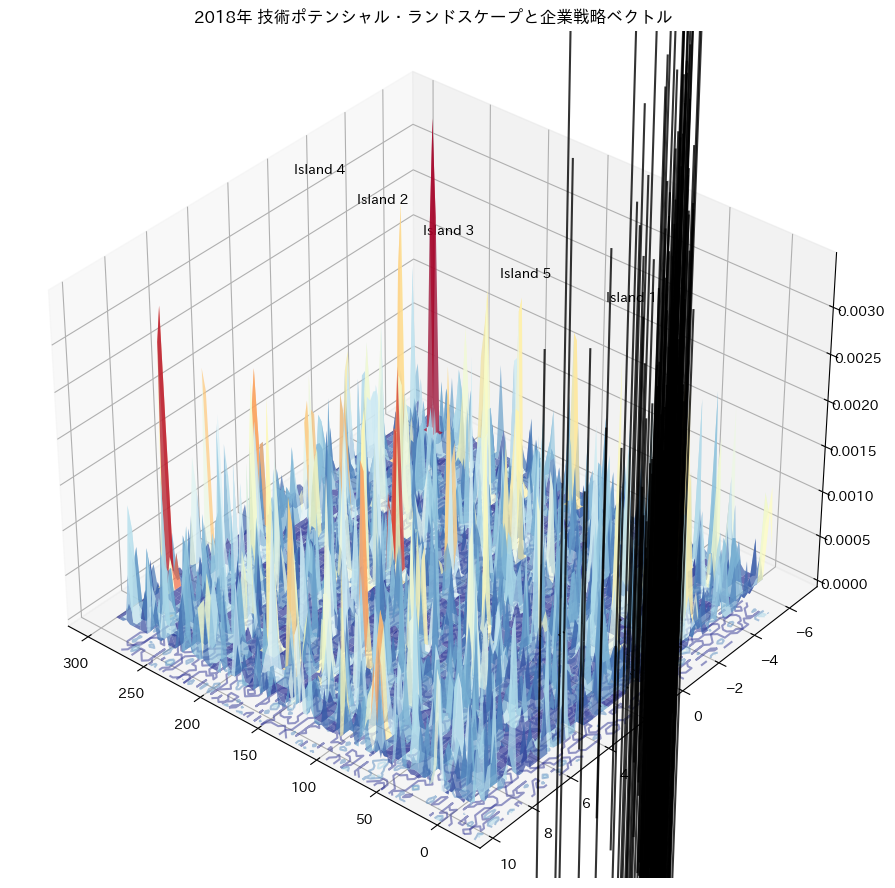

In [23]:
# ============================================================
# 【修正版】解析・可視化一括実行セル
# ============================================================
import japanize_matplotlib

# 1. 盛り上がりの定量化（同時正規分布の抽出）
# 戻り値を「df_peaks（解析表）」と「geo_data（描画用データ）」に分けて受け取ります
df_peaks, geo_data = analyze_peaks_as_gmm_v2(trained_model, 2020, graphs, df, num_corps, p_map)

# 2. 解析表の表示
print("\n### 2020年：技術ポテンシャル群島の同時正規分布解析表 ###")
# 重み（隆起の強さ）が高い順に表示し、現在の主流技術を特定します
display(df_peaks.sort_values(by="隆起強度(Weight)", ascending=False))

# 3. 3Dビジュアル可視化の実行
# 盛り上がった地形と、企業の戦略ベクトルを重ねて表示します
plot_integrated_landscape_3d(trained_model, 2018, graphs, df, num_corps, p_map, df_peaks, geo_data)

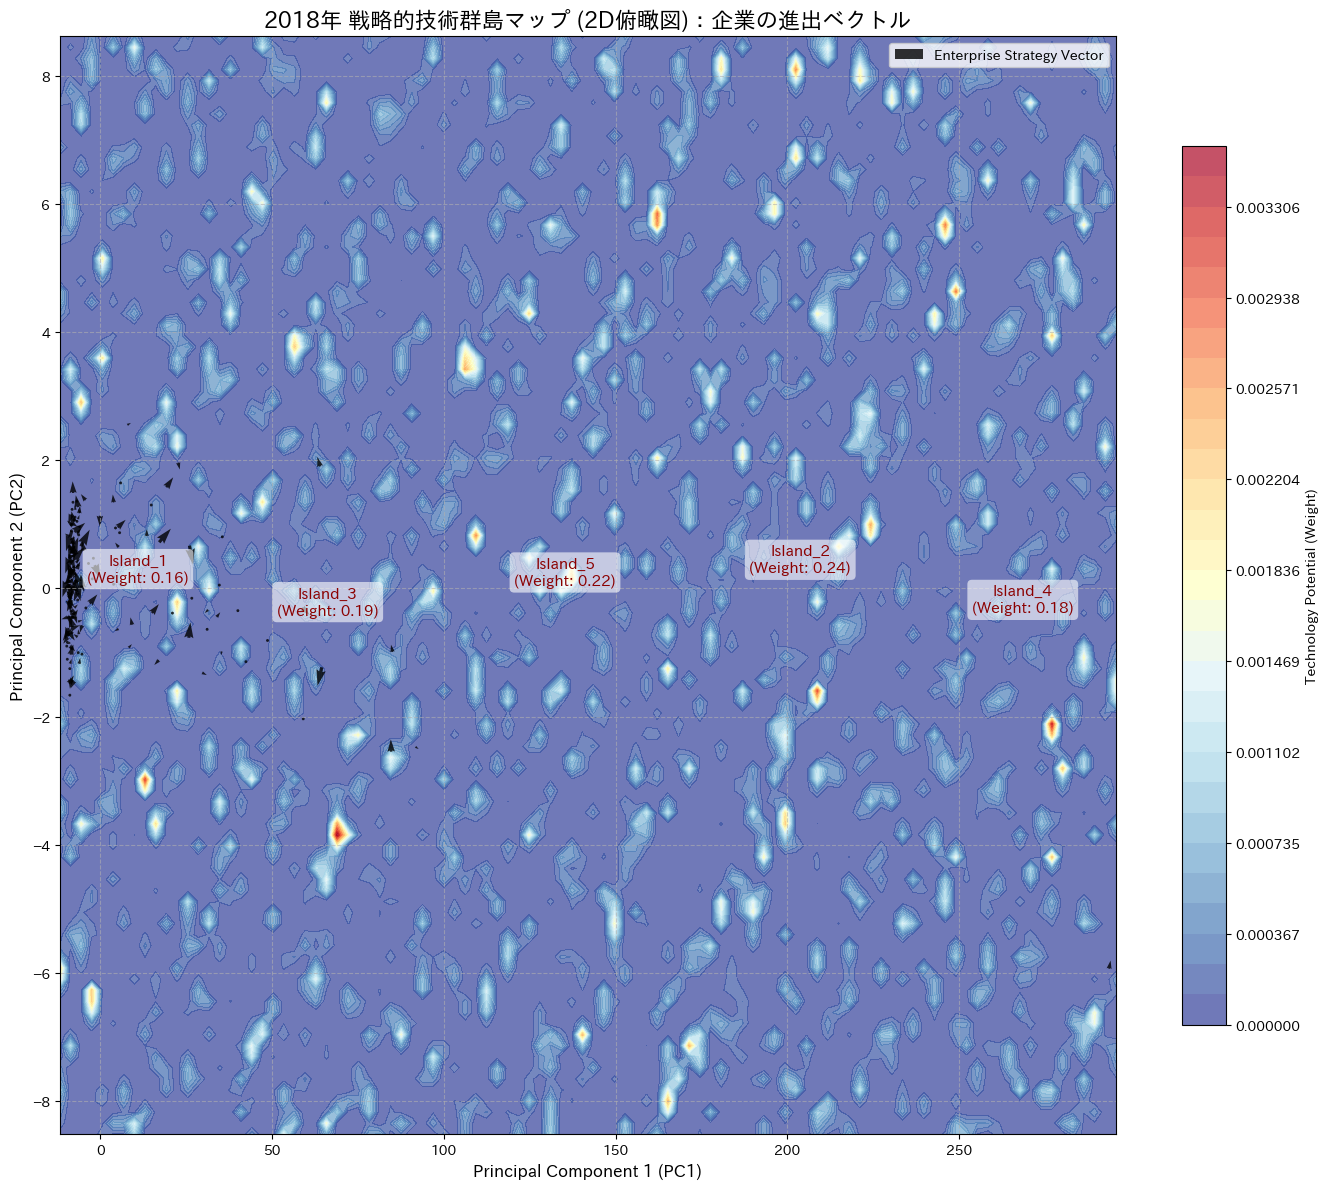

In [22]:
# ============================================================
# 実行セル：2D 戦略的群島マップの描画
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

def plot_strategic_landscape_2d(model, year, graphs, df, num_corps, p_map, df_peaks, geo_data):
    """
    盛り上がり（等高線）と企業の動き（ベクトル場）を2Dマップで表示する
    """
    # 1. データの展開
    X, Y, Z_plot, pca = geo_data
    z_corps, v_corps = extract_corp_movement(model, graphs[year], num_corps)
    
    # 2. 企業の座標とベクトルを2次元に投影
    z_2d = pca.transform(z_corps)
    v_2d = v_corps @ pca.components_.T
    
    # 3. 描画設定
    fig, ax = plt.subplots(figsize=(14, 12))
    
    # A. 地形（盛り上がり）の等高線表示
    # Peaksスタイルの鮮やかなカラーマップを使用
    levels = np.linspace(Z_plot.min(), Z_plot.max(), 30)
    contour = ax.contourf(X, Y, Z_plot, levels=levels, cmap='RdYlBu_r', alpha=0.7)
    fig.colorbar(contour, ax=ax, label='Technology Potential (Weight)', shrink=0.8)
    
    # B. 企業の戦略ベクトル場（矢印）
    # 見やすさのため、企業を間引いて表示（ここではランダムに200社）
    sample_idx = np.random.choice(len(z_2d), min(200, len(z_2d)), replace=False)
    
    # ベクトル（矢印）の描画
    # scale_units='xy', scale=0.5 で矢印の長さを物理的な移動量に合わせる
    q = ax.quiver(z_2d[sample_idx, 0], z_2d[sample_idx, 1], 
                  v_2d[sample_idx, 0], v_2d[sample_idx, 1], 
                  color='black', alpha=0.8, width=0.003, 
                  scale_units='xy', scale=0.8, pivot='tail', label='Enterprise Strategy Vector')

    # C. Island_ID のラベル表示
    # 解析表から島の中心座標を取得して配置
    for _, row in df_peaks.iterrows():
        ax.text(row['Mean_μ_PC1'], row['Mean_μ_PC2'], 
                f"Island_{int(row['Island_ID'])}\n(Weight: {row['隆起強度(Weight)']:.2f})", 
                fontweight='bold', fontsize=11, color='darkred', ha='center', va='center',
                bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', boxstyle='round'))

    # D. タイトルと軸設定
    ax.set_title(f"{year}年 戦略的技術群島マップ (2D俯瞰図)：企業の進出ベクトル", fontsize=16)
    ax.set_xlabel("Principal Component 1 (PC1)", fontsize=12)
    ax.set_ylabel("Principal Component 2 (PC2)", fontsize=12)
    ax.legend(loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

# --- 実行 ---
# 1. 解析データの準備（まだ実行していない場合）
df_peaks, geo_data = analyze_peaks_as_gmm_v2(trained_model, 2018, graphs, df, num_corps, p_map)

# 2. 2Dマップの表示
plot_strategic_landscape_2d(trained_model, 2018, graphs, df, num_corps, p_map, df_peaks, geo_data)

In [29]:
# ============================================================
# セル1: ライブラリのインポートと初期設定
# ============================================================
import pandas as pd
import numpy as np
import ast
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
from torchdiffeq import odeint
from sklearn.metrics import roc_auc_score, average_precision_score
from torch.optim.lr_scheduler import ReduceLROnPlateau
import time
import os
import warnings
import pickle
import json
from datetime import datetime
from collections import defaultdict
import time

warnings.filterwarnings('ignore')

# 再現性のためのシード設定
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


# ============================================================
# セル2: データ前処理関数の定義
# ============================================================
def safe_parse_embedding(x):
    """埋め込みベクトルを柔軟にパースする"""
    if pd.isna(x) or x == "":
        return None
    
    if isinstance(x, (list, np.ndarray)):
        return np.array(x, dtype=np.float32)
    
    if isinstance(x, str):
        try:
            s = re.sub(r'[\[\]\n]', '', x)
            s = s.replace(',', ' ')
            vals = np.array([float(v) for v in s.split() if v], dtype=np.float32)
            return vals if len(vals) > 0 else None
        except Exception:
            return None
    return None

def preprocess_data(file_path):
    """データ前処理のメイン関数"""
    print("1. データ読み込み開始...")
    df = pd.read_csv(file_path)
    
    print("2. 埋め込みベクトルを結合中...")
    combined_vectors = []
    valid_indices = []
    
    for i, row in df.iterrows():
        desc = safe_parse_embedding(row['description_embedding'])
        meta = safe_parse_embedding(row['metadata_embedding'])
        
        if desc is not None and meta is not None:
            combined_vectors.append(np.concatenate([desc, meta]))
            valid_indices.append(i)
        
        if i % 10000 == 0 and i > 0:
            print(f"  {i}件処理済み...")

    if not combined_vectors:
        print("⚠️ ベクトルが生成されません。データの中身を確認してください。")
        return pd.DataFrame()

    df = df.iloc[valid_indices].copy()
    df['combined_vector'] = combined_vectors
    print(f"  結合成功: {len(df)} 件")

    print("3. 追加の前処理（企業名・日付）を実行中...")
    def parse_corp(x):
        try:
            return ast.literal_eval(x) if isinstance(x, str) else x
        except:
            return x
    
    df["corporation"] = df["corporation"].apply(parse_corp)
    df['year_month'] = pd.to_datetime(df['year_month'])
    df = df[(df['year_month'] >= '2010-01-01') & (df['year_month'] <= '2020-12-31')]
    
    if len(df) > 0:
        v_dim = len(df.iloc[0]['combined_vector'])
        print(f"✓ 前処理完了: {len(df)} 件（次元数: {v_dim}）")
    else:
        print("⚠️ 日付フィルタリング後にデータが0件になりました。")
        
    return df


# ============================================================
# セル3: データ前処理の実行
# ============================================================
df = preprocess_data('../dataset/topic_info3.csv')
print(f"\n処理済みデータ形状: {df.shape}")
if len(df) > 0:
    print(f"ベクトル次元数: {len(df.iloc[0]['combined_vector'])}")


# ============================================================
# セル4: 動的グラフ構築関数の定義
# ============================================================
def build_global_graphs(df):
    """動的グラフの構築"""
    all_corporations = sorted(list(set([c for corps in df['corporation'] for c in corps])))
    all_patents = sorted(df['patent_number'].unique().tolist())
    
    corp_to_idx = {corp: i for i, corp in enumerate(all_corporations)}
    patent_to_idx = {patent: i + len(all_corporations) for i, patent in enumerate(all_patents)}
    total_nodes = len(all_corporations) + len(all_patents)
    
    print(f"企業数: {len(all_corporations)}, 特許数: {len(all_patents)}")
    
    # 特許特徴量の準備
    patent_features = {}
    for _, row in df.iterrows():
        patent_features[row['patent_number']] = row['combined_vector']

    global_graph_dict = {}
    year_groups = df.groupby(df['year_month'].dt.year)
    
    # 各年のリンク履歴を保存（Historical Negatives用）
    all_historical_edges = set()
    
    for year, group in year_groups:
        edges = []
        active_nodes = set()
        
        for _, row in group.iterrows():
            p_idx = patent_to_idx[row['patent_number']]
            active_nodes.add(p_idx)
            for corp in row['corporation']:
                c_idx = corp_to_idx[corp]
                edges.append([c_idx, p_idx])
                active_nodes.add(c_idx)
                all_historical_edges.add((c_idx, p_idx))
        
        if not edges:
            continue
        
        # 特徴行列の初期化
        input_dim = len(next(iter(patent_features.values())))
        x = torch.zeros(total_nodes, input_dim)
        for p_num, p_idx in patent_to_idx.items():
            if p_num in patent_features:
                x[p_idx] = torch.tensor(patent_features[p_num])
        
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        active_mask = torch.zeros(total_nodes, dtype=torch.bool)
        active_mask[list(active_nodes)] = True
        
        global_graph_dict[year] = Data(
            x=x, 
            edge_index=edge_index, 
            active_mask=active_mask, 
            year=year,
            num_nodes=total_nodes
        )
        
    return global_graph_dict, all_corporations, all_patents, patent_to_idx, total_nodes, corp_to_idx, all_historical_edges


# ============================================================
# セル5: 動的グラフの構築実行
# ============================================================
graphs, corps, patents, p_map, total_n, c_map, historical_edges = build_global_graphs(df)
num_corps = len(corps)

print(f"\n構築完了:")
print(f"  総ノード数: {total_n}")
print(f"  企業数: {num_corps}")
print(f"  特許数: {len(patents)}")
print(f"  年数: {len(graphs)}")
print(f"  年度: {sorted(graphs.keys())}")
print(f"  履歴エッジ数: {len(historical_edges)}")


# ============================================================
# セル6: 新しい評価指標の実装（MRR, Hits@K）
# ============================================================
def compute_ranking_metrics(model, z_pred, pos_edges, num_corps, all_true_edges, k_values=[1, 3, 10, 50]):
    """
    Filtered MRRとHits@Kを計算する関数
    all_true_edges: 学習・検証・テストに含まれる全正解エッジの (src, dst) セット
    """
    model.eval()
    if pos_edges.size(1) == 0:
        return None
    
    # アクティブな企業と特許を取得
    active_corps = torch.unique(pos_edges[0][pos_edges[0] < num_corps])
    active_patents = torch.unique(pos_edges[1][pos_edges[1] >= num_corps])
    
    if len(active_corps) == 0 or len(active_patents) == 0:
        return None
    
    reciprocal_ranks = []
    hits_at_k = {k: [] for k in k_values}
    
    # 計算効率のため最大1000個
    num_eval = min(pos_edges.size(1), 1000)

    # 各正例エッジについてランキングを計算
    for i in range(min(pos_edges.size(1), 1000)):  # 計算効率のため最大1000個
        src, dst = pos_edges[0, i].item(), pos_edges[1, i].item()
        filtered_negs = []
        attempts = 0
        #99個の「真のふれい（どのデータセットにも存在しないエッジ）」を探す

        # 負例候補を生成（同じ企業から他の特許へのリンク）
        neg_candidates = active_patents[active_patents != dst]
        if len(neg_candidates) < 99:
            continue
        
        # ランダムに99個サンプリング
        while len(filtered_negs) < 99 and attempts < 1000:
            neg_dst = active_patents[torch.randint(len(active_patents), (1,))].item()
            # ターゲット(src, dst)そのものではなく、かつ全正解データに含まれていない場合のみ採用
            if neg_dst != dst and (src, neg_dst) not in all_true_edges:
                filtered_negs.append(neg_dst)
            attempts += 1
        
        if len(filtered_negs) < 99:
            continue # 負例が十分に確保できない場合はスキップ
            
        # 正例1個 + 負例99個
        all_dsts = torch.tensor([dst] + filtered_negs, device=device)
        src_repeated = torch.tensor([src] * len(all_dsts), device=device)
        candidate_edges = torch.stack([src_repeated, all_dsts])
        
        with torch.no_grad():
            scores = model.decode(z_pred, candidate_edges).cpu().numpy()
        
        # 順位計算（高いスコアほど上位）
        rank = (scores > scores[0]).sum() + 1
        reciprocal_ranks.append(1.0 / rank)
        
        for k in k_values:
            hits_at_k[k].append(1.0 if rank <= k else 0.0)
    
    if not reciprocal_ranks:
        return None
    
    metrics = {'mrr': np.mean(reciprocal_ranks), 'num_samples': len(reciprocal_ranks)}
    for k in k_values:
        metrics[f'hits@{k}'] = np.mean(hits_at_k[k])
    
    return metrics

# ============================================================
# セル7-8: ベースラインモデル (コメントアウト)
# ============================================================
"""
class EdgeBank: ...
class GraphMixer: ...
"""

# ============================================================
# セル9: エンコーダ定義 (既存のまま)
# ============================================================
class SharedVGAEEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels * 2, heads=2, concat=False)
        self.conv2 = GATConv(hidden_channels * 2, hidden_channels, heads=2, concat=False)
        self.conv3 = GATConv(hidden_channels, hidden_channels, heads=1, concat=False)
        self.conv_mu = GATConv(hidden_channels, out_channels, heads=1, concat=False)
        self.conv_logvar = GATConv(hidden_channels, out_channels, heads=1, concat=False)
        self.dropout = nn.Dropout(0.2)
        self.batch_norm1 = nn.BatchNorm1d(hidden_channels * 2)
        self.batch_norm2 = nn.BatchNorm1d(hidden_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.batch_norm1(self.conv1(x, edge_index)))
        x = self.dropout(x)
        x = F.relu(self.batch_norm2(self.conv2(x, edge_index)))
        x = self.dropout(x)
        x = F.relu(self.conv3(x, edge_index))
        return self.conv_mu(x, edge_index), self.conv_logvar(x, edge_index)

# ============================================================
# セル10 (修正): 高解像度・安定化したPotentialNet
# ============================================================
class PotentialNet(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()

        # 空間の解像度を上げるためのランダム周波数行列
        self.B = nn.Parameter(torch.randn(latent_dim, hidden_dim // 2) * 5.0, requires_grad=False)

        input_features = hidden_dim
        
        # 層を深くし、Dropoutを加えることで一方向の単純な壁になるのを防ぐ
        self.net = nn.Sequential(
            nn.Linear(input_features, hidden_dim * 2),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, 1),
            nn.Tanh() # 出力を -1 ~ 1 に正規化
        )

    def forward(self, z):
        # 座標 z を高周波に変換することで「島」を作りやすくする
        proj = torch.matmul(z, self.B)
        x = torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)
        return self.net(x)

    def compute_potential_grid(self, x_range, y_range, resolution=50, device='cpu'):
        """グリッド上でポテンシャルを計算"""
        x = torch.linspace(x_range[0], x_range[1], resolution)
        y = torch.linspace(y_range[0], y_range[1], resolution)
        X, Y = torch.meshgrid(x, y, indexing='ij')
        
        grid_points = torch.stack([X.flatten(), Y.flatten()], dim=1).to(device)
        with torch.no_grad():
            potentials = self.forward(grid_points)
        
        return X.cpu().numpy(), Y.cpu().numpy(), potentials.view(resolution, resolution).cpu().numpy()
    
class GradientODEFunc(nn.Module):
    def __init__(self, potential_net):
        super().__init__()
        self.potential_net = potential_net
        self.scale = nn.Parameter(torch.tensor(0.1))

    def forward(self, t, z):
        with torch.set_grad_enabled(True):
            z_in = z.detach().requires_grad_(True)
            phi = self.potential_net(z_in)
            grad_z = torch.autograd.grad(phi.sum(), z_in, create_graph=True)[0]
        return torch.tanh(self.scale) * grad_z
    
    def compute_gradient_field(self, X, Y, device='cpu'):
        """グリッド上で勾配ベクトル場を計算"""
        grid_points = torch.tensor(
            np.stack([X.flatten(), Y.flatten()], axis=1), 
            dtype=torch.float32, device=device, requires_grad=True
        )
        
        phi = self.potential_net(grid_points)
        gradients = torch.autograd.grad(phi.sum(), grid_points, create_graph=False)[0]
        
        grad_x = gradients[:, 0].view(X.shape).cpu().numpy()
        grad_y = gradients[:, 1].view(X.shape).cpu().numpy()
        
        return grad_x, grad_y

class GradientNeuralODEPredictor(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        self.potential_net = PotentialNet(latent_dim, hidden_dim)
        self.ode_func = GradientODEFunc(self.potential_net)

    def forward(self, z_current, delta_t=1.0):
        t_span = torch.tensor([0., delta_t], device=z_current.device)
        z_future = odeint(
            self.ode_func, z_current, t_span,
            method='dopri5', rtol=1e-3, atol=1e-3
        )[-1]
        return z_future

# ============================================================
# セル11: 統合VGAEモデル (Gradient ODE専用)
# ============================================================
class UnifiedVGAE(nn.Module):
    def __init__(self, num_nodes, num_corps, input_dim, hidden_dim=256,
                 latent_dim=2, sequence_length=3):
        super().__init__()
        self.num_nodes = num_nodes
        self.num_corps = num_corps
        self.latent_dim = latent_dim
        self.input_dim = input_dim
        self.sequence_length = sequence_length

        self.corp_embeddings = nn.Embedding(num_corps, input_dim)
        nn.init.normal_(self.corp_embeddings.weight, mean=0.0, std=0.05)
        self.encoder = SharedVGAEEncoder(input_dim, hidden_dim, latent_dim)
        self.temporal_predictor = GradientNeuralODEPredictor(latent_dim, hidden_dim)

        self.link_predictor = nn.Sequential(
            nn.Linear(latent_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, 1)
        )

    def get_node_features(self, x, node_indices=None):
        features = x.clone()
        corp_mask = node_indices < self.num_corps
        if corp_mask.any():
            features[corp_mask] = self.corp_embeddings(node_indices[corp_mask])
        return features

    def encode(self, x, edge_index, node_indices=None):
        if node_indices is None:
            node_indices = torch.arange(self.num_nodes, device=x.device)
        x_features = self.get_node_features(x, node_indices)
        mu, logvar = self.encoder(x_features, edge_index)
        z = self.reparameterize(mu, logvar)
        return z, mu, logvar

    def reparameterize(self, mu, logvar):
        if self.training:
            return mu + torch.randn_like(logvar) * torch.exp(0.5 * logvar)
        return mu

    def decode(self, z, edge_index):
        return torch.sigmoid(self.link_predictor(torch.cat([z[edge_index[0]], z[edge_index[1]]], dim=-1))).squeeze()

    def predict_future(self, z_history_list):
        return self.temporal_predictor(z_history_list[-1])
# ============================================================
# セル12: 負例サンプリング関数
# ============================================================
def sample_hard_negatives_v2(model, z, active_corps, active_patents, 
                             pos_set, historical_edges, num_samples=500):
    """
    Historical Negatives を含む負例サンプリング
    """
    if len(active_corps) == 0 or len(active_patents) == 0:
        return None
    
    neg_edges = []
    attempts = 0
    max_attempts = num_samples * 10
    
    while len(neg_edges) < num_samples and attempts < max_attempts:
        corp_idx = active_corps[torch.randint(len(active_corps), (1,))].item()
        patent_idx = active_patents[torch.randint(len(active_patents), (1,))].item()
        
        edge = (corp_idx, patent_idx)
        # 正例でも履歴にも存在しないエッジのみ採用
        if edge not in pos_set and edge not in historical_edges:
            neg_edges.append([corp_idx, patent_idx])
        
        attempts += 1
    
    if len(neg_edges) == 0:
        return None
    
    return torch.tensor(neg_edges, dtype=torch.long, device=z.device).t().contiguous()


# ============================================================
# セル13 (完全修正版): 損失関数
# ============================================================
def compute_loss_standardized(model, data_t, data_t1, num_corps, 
                              z_history_for_prediction, historical_edges,
                              beta=0.01, pos_weight=5.0, 
                              latent_pred_weight=1.0, future_link_weight=1.0,
                              potential_weight=15.0):
    """
    統合損失関数
    
    Args:
        model: UnifiedVGAE
        data_t: 現在時刻のグラフデータ
        data_t1: 次時刻のグラフデータ
        num_corps: 企業数
        z_history_for_prediction: リスト [z_{t-2}, z_{t-1}, z_t]
        historical_edges: 履歴エッジのセット
        
    Returns:
        total_loss: スカラー損失
        loss_dict: 各損失の辞書
    """
    try:
        device = data_t.x.device
        node_indices = torch.arange(model.num_nodes, device=device)
        
        # ============================================================
        # 1. 現在時刻 t のエンコード
        # ============================================================
        z_t, mu_t, logvar_t = model.encode(data_t.x, data_t.edge_index, node_indices)
        
        # ============================================================
        # 2. 再構成損失 (現在時刻 t)
        # ============================================================
        pos_edge_index_t = data_t.edge_index
        active_corps_t = torch.unique(pos_edge_index_t[0][pos_edge_index_t[0] < num_corps])
        active_patents_t = torch.unique(pos_edge_index_t[1][pos_edge_index_t[1] >= num_corps])
        pos_set_t = set(tuple(p.tolist()) for p in pos_edge_index_t.t())
        
        neg_edge_index_t = sample_hard_negatives_v2(
            model, z_t, active_corps_t, active_patents_t, 
            pos_set_t, historical_edges, num_samples=500
        )
        
        recon_loss_t = torch.tensor(0.0, device=device)
        if neg_edge_index_t is not None and neg_edge_index_t.size(1) > 0:
            pos_pred_t = model.decode(z_t, pos_edge_index_t)
            neg_pred_t = model.decode(z_t, neg_edge_index_t)
            recon_loss_t = (
                -torch.log(pos_pred_t + 1e-15).mean() * pos_weight 
                - torch.log(1 - neg_pred_t + 1e-15).mean()
            )
        
        # KL損失
        kl_loss_t = -0.5 * torch.mean(
            1 + logvar_t[data_t.active_mask] 
            - mu_t[data_t.active_mask].pow(2) 
            - logvar_t[data_t.active_mask].exp()
        )
        
        # ============================================================
        # 3. ポテンシャル損失（ランクベース）
        # ============================================================
        patents_in_t = data_t.edge_index[1]
        unique_patents, counts = torch.unique(patents_in_t, return_counts=True)
        
        # ターゲットの初期化
        target_phi = torch.zeros(model.num_nodes, 1, device=device)
        target_phi[unique_patents] = counts.view(-1, 1).float()
        
        # 特許マスク
        patent_mask = (node_indices >= num_corps) & data_t.active_mask
        patent_counts = target_phi[patent_mask]
        
        # ランク正規化
        if patent_counts.numel() > 1:
            ranks = torch.argsort(torch.argsort(patent_counts, dim=0), dim=0).float()
            normalized_ranks = ranks / (ranks.max() + 1e-9)
            target_phi[patent_mask] = (normalized_ranks * 2.0) - 1.0
        
        # 予測ポテンシャル
        predicted_phi = model.temporal_predictor.potential_net(mu_t)
        mse_loss = F.mse_loss(predicted_phi[patent_mask], target_phi[patent_mask])
        
        # 背景ペナルティ
        background_penalty = torch.mean(predicted_phi ** 2)
        potential_loss = mse_loss + 0.5 * background_penalty
        
        # ============================================================
        # 4. 未来予測損失（重要な修正箇所）
        # ============================================================
        # z_history_for_prediction は [z_{t-2}, z_{t-1}, z_t] のリスト
        if z_history_for_prediction is not None and len(z_history_for_prediction) > 0:
            # ODEで t+1 を予測
            z_t1_pred = model.predict_future(z_history_for_prediction)
            
            # 実際の t+1 をエンコード
            with torch.no_grad():
                _, mu_t1_actual, _ = model.encode(data_t1.x, data_t1.edge_index, node_indices)
            
            # 潜在空間の予測損失
            latent_pred_loss = F.mse_loss(
                z_t1_pred[data_t1.active_mask], 
                mu_t1_actual[data_t1.active_mask]
            )
        else:
            latent_pred_loss = torch.tensor(0.0, device=device)
        
        # ============================================================
        # 5. 未来リンク予測損失
        # ============================================================
        pos_edge_index_t1 = data_t1.edge_index
        future_link_loss = torch.tensor(0.0, device=device)
        
        if pos_edge_index_t1.size(1) > 0 and z_history_for_prediction is not None:
            active_corps_t1 = torch.unique(pos_edge_index_t1[0][pos_edge_index_t1[0] < num_corps])
            active_patents_t1 = torch.unique(pos_edge_index_t1[1][pos_edge_index_t1[1] >= num_corps])
            pos_set_t1 = set(tuple(p.tolist()) for p in pos_edge_index_t1.t())
            
            neg_t1 = sample_hard_negatives_v2(
                model, z_t1_pred, active_corps_t1, active_patents_t1, 
                pos_set_t1, historical_edges, num_samples=300
            )
            
            if neg_t1 is not None and neg_t1.size(1) > 0:
                future_link_loss = (
                    -torch.log(model.decode(z_t1_pred, pos_edge_index_t1) + 1e-15).mean() * pos_weight
                    - torch.log(1 - model.decode(z_t1_pred, neg_t1) + 1e-15).mean()
                )
        
        # ============================================================
        # 6. 総損失
        # ============================================================
        total_loss = (
            recon_loss_t 
            + beta * kl_loss_t 
            + latent_pred_weight * latent_pred_loss 
            + future_link_weight * future_link_loss 
            + potential_weight * potential_loss
        )
        
        loss_dict = {
            'total_loss': total_loss.item(),
            'recon_loss': recon_loss_t.item(),
            'kl_loss': kl_loss_t.item(),
            'latent_pred_loss': latent_pred_loss.item(),
            'future_link_loss': future_link_loss.item(),
            'potential_loss': potential_loss.item()
        }
        
        return total_loss, loss_dict
        
    except Exception as e:
        print(f"⚠️ 損失計算エラー: {e}")
        return (torch.tensor(0.0, device=device, requires_grad=True), 
                {'total_loss': 0.0, 'potential_loss': 0.0, 'future_link_loss': 0.0})


# ============================================================
# セル14: 学習ループ（修正版）
# ============================================================
def train_model_improved(model, global_graph_dict, num_corps, model_name, 
                        historical_edges, num_epochs=20):
    """
    改善版学習ループ
    """
    device = next(model.parameters()).device
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3, verbose=True)
    
    years = sorted(global_graph_dict.keys())
    train_years = years[:int(len(years) * 0.7)]
    val_years = years[int(len(years) * 0.7):int(len(years) * 0.85)]
    test_years = years[int(len(years) * 0.85):]
    
    print(f"学習期間: {train_years}")
    print(f"検証期間: {val_years}")
    print(f"テスト期間: {test_years}")
    
    # 全正解エッジを収集
    all_true_edges = set()
    for year_list in [train_years, val_years, test_years]:
        for year in year_list:
            edges = global_graph_dict[year].edge_index.t().tolist()
            all_true_edges.update([tuple(e) for e in edges])
    
    best_val_mrr = 0.0
    best_model_state = None
    history = {'train_loss': [], 'val_mrr': []}
    
    start_time = time.time()
    
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        num_batches = 0
        
        # 学習ループ
        for i in range(len(train_years) - 1):
            year_t = train_years[i]
            year_t1 = train_years[i + 1]
            
            data_t = global_graph_dict[year_t].to(device)
            data_t1 = global_graph_dict[year_t1].to(device)
            
            # 履歴の構築（過去3時点）
            z_history = []
            for j in range(max(0, i - 2), i + 1):
                with torch.no_grad():
                    data_hist = global_graph_dict[train_years[j]].to(device)
                    z_hist, _, _ = model.encode(data_hist.x, data_hist.edge_index)
                    z_history.append(z_hist)
            
            # 損失計算
            optimizer.zero_grad()
            loss, loss_dict = compute_loss_standardized(
                model, data_t, data_t1, num_corps, 
                z_history, historical_edges
            )
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            epoch_loss += loss.item()
            num_batches += 1
        
        avg_train_loss = epoch_loss / max(num_batches, 1)
        history['train_loss'].append(avg_train_loss)
        
        # 検証
        model.eval()
        val_mrr_list = []
        
        for i in range(len(val_years) - 1):
            year_t = val_years[i]
            year_t1 = val_years[i + 1]
            
            data_t = global_graph_dict[year_t].to(device)
            data_t1 = global_graph_dict[year_t1].to(device)
            
            # 履歴構築
            z_history = []
            look_back_years = [y for y in years if y < year_t1][-3:]
            for y in look_back_years:
                with torch.no_grad():
                    data_hist = global_graph_dict[y].to(device)
                    z_hist, _, _ = model.encode(data_hist.x, data_hist.edge_index)
                    z_history.append(z_hist)
            
            # 予測
            with torch.no_grad():
                if len(z_history) > 0:
                    z_pred = model.predict_future(z_history)
                else:
                    z_pred, _, _ = model.encode(data_t1.x, data_t1.edge_index)
            
            # 評価
            metrics = compute_ranking_metrics(
                model, z_pred, data_t1.edge_index, num_corps, 
                all_true_edges, k_values=[1, 3, 10, 50]
            )
            
            if metrics:
                val_mrr_list.append(metrics['mrr'])
        
        val_mrr = np.mean(val_mrr_list) if val_mrr_list else 0.0
        history['val_mrr'].append(val_mrr)
        
        # ベストモデル保存
        if val_mrr > best_val_mrr:
            best_val_mrr = val_mrr
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        
        scheduler.step(val_mrr)
        
        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train Loss: {avg_train_loss:.4f} | "
              f"Val MRR: {val_mrr:.4f} | "
              f"Best: {best_val_mrr:.4f}")
    
    # ベストモデルをロード
    if best_model_state:
        model.load_state_dict({k: v.to(device) for k, v in best_model_state.items()})
    
    training_time = time.time() - start_time
    
    return model, best_val_mrr, history, training_time

# ============================================================
# セル13 (修正版): ランクベース順位制を用いた損失関数
# ============================================================
def compute_loss_standardized(model, data_t, data_t1, num_corps, z_history_for_prediction,
                              historical_edges, beta=0.01, pos_weight=5.0, 
                              latent_pred_weight=1.0, future_link_weight=1.0,
                              potential_weight=15.0): # 重みを強化
    try:
        node_indices = torch.arange(model.num_nodes, device=device)
        z_t, mu_t, logvar_t = model.encode(data_t.x, data_t.edge_index)
        
        # 1. 再構成損失 (t)
        pos_edge_index_t = data_t.edge_index
        active_corps_t = torch.unique(pos_edge_index_t[0][pos_edge_index_t[0] < num_corps])
        active_patents_t = torch.unique(pos_edge_index_t[1][pos_edge_index_t[1] >= num_corps])
        pos_set_t = set(tuple(p.tolist()) for p in pos_edge_index_t.t())
        neg_edge_index_t = sample_hard_negatives_v2(model, z_t, active_corps_t, active_patents_t, 
                                                    pos_set_t, historical_edges, num_samples=500)
        
        recon_loss_t = torch.tensor(0.0, device=device)
        if neg_edge_index_t is not None:
            pos_pred_t = model.decode(z_t, pos_edge_index_t)
            neg_pred_t = model.decode(z_t, neg_edge_index_t)
            recon_loss_t = -torch.log(pos_pred_t + 1e-15).mean() * pos_weight - torch.log(1 - neg_pred_t + 1e-15).mean()

        kl_loss_t = -0.5 * torch.mean(1 + logvar_t[data_t.active_mask] - mu_t[data_t.active_mask].pow(2) - logvar_t[data_t.active_mask].exp())

        # ------------------------------------------------------------
        # 2. 技術ポテンシャルの学習（ランクベース順位制）
        # ------------------------------------------------------------
        patents_in_t = data_t.edge_index[1]
        unique_patents, counts = torch.unique(patents_in_t, return_counts=True)
        target_phi = torch.zeros(model.num_nodes, 1, device=device)
        target_phi[unique_patents] = counts.view(-1, 1).float()
        
        patent_mask = (node_indices >= num_corps) & data_t.active_mask
        patent_counts = target_phi[patent_mask]
        
        if patent_counts.numel() > 1:
            # 順位（ランク）を計算し、0.0 ~ 1.0 に正規化
            ranks = torch.argsort(torch.argsort(patent_counts, dim=0), dim=0).float()
            normalized_ranks = ranks / (ranks.max() + 1e-9)
            # ターゲットを -1.0 ~ 1.0 に変換して「民主的な山作り」を促進
            target_phi[patent_mask] = (normalized_ranks * 2.0) - 1.0 
        
        predicted_phi = model.temporal_predictor.potential_net(mu_t)
        mse_loss = F.mse_loss(predicted_phi[patent_mask], target_phi[patent_mask])

        # 背景ペナルティ：全ノードのポテンシャルの平均を 0 に近づけることで「壁」になるのを防ぐ
        background_penalty = torch.mean(predicted_phi**2)
        potential_loss = mse_loss + 0.5 * background_penalty

        # 3. 未来予測損失
        z_t1_pred = model.predict_future(z_history_for_prediction)
        with torch.no_grad():
            _, mu_t1_actual, _ = model.encode(data_t1.x, data_t1.edge_index)
        latent_pred_loss = F.mse_loss(z_t1_pred[data_t1.active_mask], mu_t1_actual[data_t1.active_mask])

        # 未来リンク予測 (t1)
        pos_edge_index_t1 = data_t1.edge_index
        future_link_loss = torch.tensor(0.0, device=device)
        if pos_edge_index_t1.size(1) > 0:
            active_corps_t1 = torch.unique(pos_edge_index_t1[0][pos_edge_index_t1[0] < num_corps])
            active_patents_t1 = torch.unique(pos_edge_index_t1[1][pos_edge_index_t1[1] >= num_corps])
            pos_set_t1 = set(tuple(p.tolist()) for p in pos_edge_index_t1.t())
            neg_t1 = sample_hard_negatives_v2(model, z_t1_pred, active_corps_t1, active_patents_t1, pos_set_t1, historical_edges, num_samples=300)
            if neg_t1 is not None:
                future_link_loss = -torch.log(model.decode(z_t1_pred, pos_edge_index_t1) + 1e-15).mean() * pos_weight - \
                                   torch.log(1 - model.decode(z_t1_pred, neg_t1) + 1e-15).mean()

        total_loss = recon_loss_t + beta * kl_loss_t + latent_pred_weight * latent_pred_loss + future_link_weight * future_link_loss + potential_weight * potential_loss
        return total_loss, {'total_loss': total_loss.item(), 'potential_loss': potential_loss.item(), 'future_link_loss': future_link_loss.item()}
    except Exception as e:
        return torch.tensor(0.0, device=device, requires_grad=True), {'total_loss': 0.0, 'future_link_loss': 0.0}

# ============================================================
# メイン実行：Gradient Neural ODE のみの学習
# ============================================================
print(">>> Gradient Neural ODE の学習を開始します...")

model_gradient_ode = UnifiedVGAE(
    num_nodes=total_n, num_corps=num_corps, input_dim=input_dim,
    hidden_dim=64, latent_dim=16, sequence_length=3
).to(device)

trained_model_gradient_ode, best_mrr_gradient_ode, history_gradient_ode, time_gradient_ode = train_model_improved(
    model_gradient_ode, graphs, num_corps, "VGAE+GradientODE_RankBased", historical_edges, num_epochs=10
)

print(f"\n学習完了: VGAE + Gradient ODE (順位制ターゲット)")
print(f"Best Validation MRR: {best_mrr_gradient_ode:.4f}")

Using device: cuda
1. データ読み込み開始...
2. 埋め込みベクトルを結合中...
  10000件処理済み...
  20000件処理済み...
  30000件処理済み...
  40000件処理済み...
  結合成功: 42789 件
3. 追加の前処理（企業名・日付）を実行中...
✓ 前処理完了: 19389 件（次元数: 1088）

処理済みデータ形状: (19389, 20)
ベクトル次元数: 1088
企業数: 2450, 特許数: 19384

構築完了:
  総ノード数: 21834
  企業数: 2450
  特許数: 19384
  年数: 11
  年度: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]
  履歴エッジ数: 27274
>>> Gradient Neural ODE の学習を開始します...
学習期間: [2010, 2011, 2012, 2013, 2014, 2015, 2016]
検証期間: [2017, 2018]
テスト期間: [2019, 2020]
Epoch 1/10 | Train Loss: 15.6932 | Val MRR: 0.0522 | Best: 0.0522
Epoch 2/10 | Train Loss: 15.5221 | Val MRR: 0.0509 | Best: 0.0522
Epoch 3/10 | Train Loss: 15.5444 | Val MRR: 0.0517 | Best: 0.0522
Epoch 4/10 | Train Loss: 15.3918 | Val MRR: 0.0484 | Best: 0.0522
Epoch 5/10 | Train Loss: 15.0297 | Val MRR: 0.0550 | Best: 0.0550
Epoch 6/10 | Train Loss: 14.3372 | Val MRR: 0.0518 | Best: 0.0550
Epoch 7/10 | Train Loss: 14.2176 | Val MRR: 0.0567 | Best: 0.0567
Epoch 8/10 | Train Lo

In [31]:
trained_model_gradient_ode

UnifiedVGAE(
  (corp_embeddings): Embedding(2450, 1088)
  (encoder): SharedVGAEEncoder(
    (conv1): GATConv(1088, 128, heads=2)
    (conv2): GATConv(128, 64, heads=2)
    (conv3): GATConv(64, 64, heads=1)
    (conv_mu): GATConv(64, 16, heads=1)
    (conv_logvar): GATConv(64, 16, heads=1)
    (dropout): Dropout(p=0.2, inplace=False)
    (batch_norm1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (batch_norm2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (temporal_predictor): GradientNeuralODEPredictor(
    (potential_net): PotentialNet(
      (net): Sequential(
        (0): Linear(in_features=64, out_features=128, bias=True)
        (1): LeakyReLU(negative_slope=0.2)
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=128, out_features=64, bias=True)
        (4): LeakyReLU(negative_slope=0.2)
        (5): Linear(in_features=64, out_features=1, bias=True)
        (6): Tanh()
      )


In [32]:
best_mrr_gradient_ode

0.057527754721620875

In [33]:
history_gradient_ode

{'train_loss': [15.693190097808838,
  15.52211364110311,
  15.544438362121582,
  15.391818205515543,
  15.029725869496664,
  14.33723783493042,
  14.217602729797363,
  14.050351778666178,
  14.011104742685953,
  14.09048318862915],
 'val_mrr': [0.05215182345615749,
  0.05090399951273704,
  0.05165298577160584,
  0.04840838677525812,
  0.05503265272538306,
  0.051813452056707926,
  0.05673610299639845,
  0.05283959824122196,
  0.052074011513827956,
  0.057527754721620875]}

In [34]:
time_gradient_ode

29.379718542099

In [36]:
# 診断コード: 各損失成分を確認
def diagnose_training(history):
    """学習状態の診断"""
    print("=" * 60)
    print("学習診断レポート")
    print("=" * 60)
    
    # 1. 損失の減少率
    initial_loss = history['train_loss'][0]
    final_loss = history['train_loss'][-1]
    reduction = (initial_loss - final_loss) / initial_loss * 100
    print(f"\n1. 損失の減少")
    print(f"   初期: {initial_loss:.4f} → 最終: {final_loss:.4f}")
    print(f"   減少率: {reduction:.2f}%")
    
    if reduction < 15:
        print("   ⚠️ 問題: 損失が十分に減少していない")
        print("   → 学習率を上げる、モデル容量を増やす")
    
    # 2. MRRの安定性
    mrr_std = np.std(history['val_mrr'])
    mrr_mean = np.mean(history['val_mrr'])
    print(f"\n2. MRRの安定性")
    print(f"   平均: {mrr_mean:.4f}, 標準偏差: {mrr_std:.4f}")
    print(f"   変動係数: {mrr_std/mrr_mean:.2%}")
    
    if mrr_std / mrr_mean > 0.1:
        print("   ⚠️ 問題: MRRが不安定")
        print("   → 学習率を下げる、正則化を強化")
    
    # 3. 過学習のチェック
    if len(history['train_loss']) >= 5:
        last_5_loss = history['train_loss'][-5:]
        loss_trend = np.polyfit(range(5), last_5_loss, 1)[0]
        
        last_5_mrr = history['val_mrr'][-5:]
        mrr_trend = np.polyfit(range(5), last_5_mrr, 1)[0]
        
        print(f"\n3. 過学習の診断")
        print(f"   直近5エポックの損失トレンド: {loss_trend:.4f}")
        print(f"   直近5エポックのMRRトレンド: {mrr_trend:.4f}")
        
        if loss_trend < -0.1 and mrr_trend < 0:
            print("   ⚠️ 過学習の兆候: 損失は減るがMRRが改善しない")
            print("   → Dropout強化、Early Stopping")
    
    # 4. 最適なMRRの確認
    best_mrr = max(history['val_mrr'])
    best_epoch = history['val_mrr'].index(best_mrr) + 1
    print(f"\n4. 最良の結果")
    print(f"   Best MRR: {best_mrr:.4f} (Epoch {best_epoch})")
    
    if best_mrr < 0.1:
        print("   ⚠️ 問題: MRRが低すぎる")
        print("   → モデルアーキテクチャの見直しが必要")
    
    print("=" * 60)

# 実行
diagnose_training(history_gradient_ode)

学習診断レポート

1. 損失の減少
   初期: 15.6932 → 最終: 14.0905
   減少率: 10.21%
   ⚠️ 問題: 損失が十分に減少していない
   → 学習率を上げる、モデル容量を増やす

2. MRRの安定性
   平均: 0.0529, 標準偏差: 0.0026
   変動係数: 4.96%

3. 過学習の診断
   直近5エポックの損失トレンド: -0.0700
   直近5エポックのMRRトレンド: 0.0007

4. 最良の結果
   Best MRR: 0.0575 (Epoch 10)
   ⚠️ 問題: MRRが低すぎる
   → モデルアーキテクチャの見直しが必要



========================== 抜本的改善版モデル: 学習開始 ===========================

モデル情報:
  総パラメータ数: 2,249,666
  学習可能: 2,249,666

学習設定:
  学習期間: [2010, 2011, 2012, 2013, 2014, 2015, 2016]
  検証期間: [2017, 2018]
  初期学習率: 0.005
  Patience: 8

✓ New best model at epoch 1

Epoch 1/40
  Train Loss: 12.5261 [Link: 12.172, Future: 0.707, KL: 0.8013]
  Val MRR: 0.0561 (Best: 0.0561)
  Hits@10: 0.1180, Hits@50: 0.5160
  LR: 0.005000, Patience: 0/8
✓ New best model at epoch 5

Epoch 5/40
  Train Loss: 1.3241 [Link: 1.110, Future: 0.428, KL: 1.6084]
  Val MRR: 0.0714 (Best: 0.0714)
  Hits@10: 0.1640, Hits@50: 0.6130
  LR: 0.005000, Patience: 0/8

Epoch 10/40
  Train Loss: 0.8732 [Link: 0.706, Future: 0.334, KL: 1.6987]
  Val MRR: 0.0505 (Best: 0.0714)
  Hits@10: 0.1010, Hits@50: 0.5180
  LR: 0.005000, Patience: 5/8

早期停止: Epoch 13でMRRが8エポック改善せず

✓ ベストモデル (MRR=0.0714) をロードしました

================================ 学習完了 ================================

ベストモデル:
  Validation MRR: 0.0714
  前回からの改善: +0.0139 (+24.2%)
 

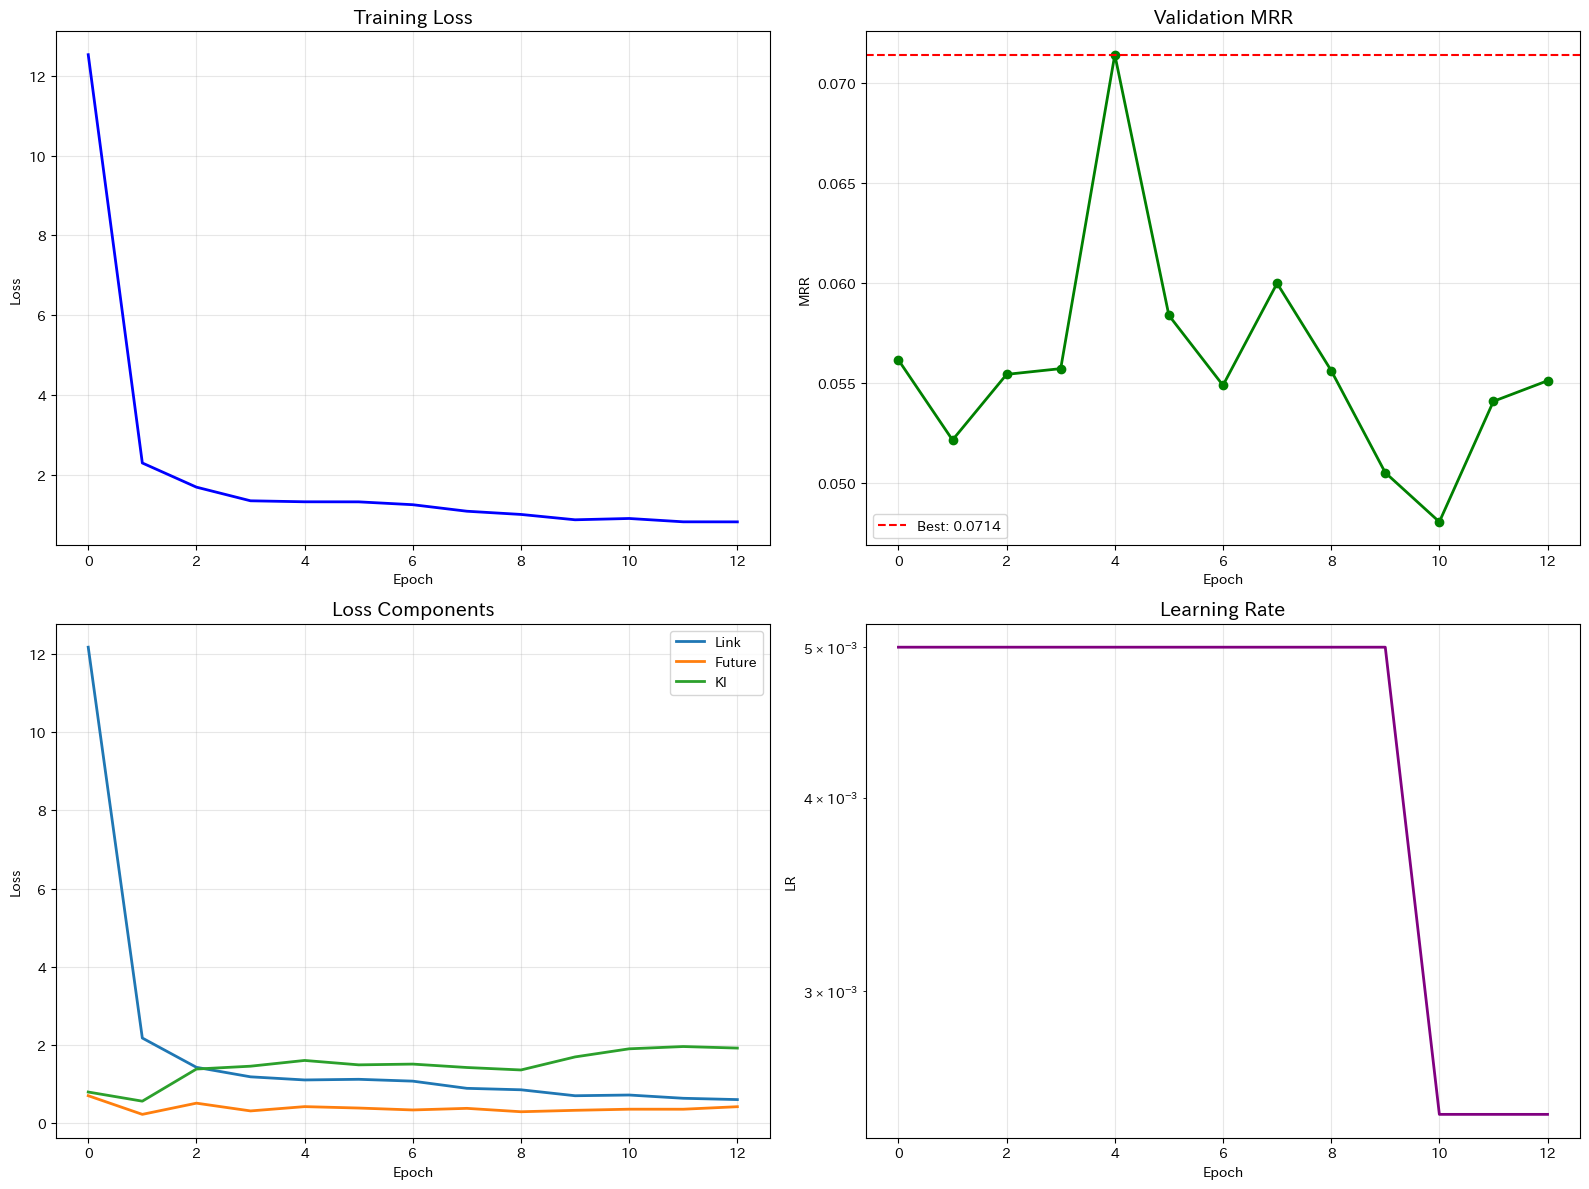


✓ 学習曲線を 'radical_training_history.png' に保存しました


In [39]:
# ============================================================
# 完全版: 学習ループ（損失関数を統一）
# ============================================================
def train_model_radical(model, global_graph_dict, num_corps, model_name, 
                       historical_edges, num_epochs=40, patience=8):
    """
    抜本的改善版の学習ループ
    """
    device = next(model.parameters()).device
    
    # オプティマイザ
    optimizer = torch.optim.AdamW(
        model.parameters(), 
        lr=0.005,  # 初期学習率
        weight_decay=1e-4,
        betas=(0.9, 0.999)
    )
    
    # スケジューラ
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=4, verbose=True, min_lr=1e-6
    )
    
    years = sorted(global_graph_dict.keys())
    train_years = years[:int(len(years) * 0.7)]
    val_years = years[int(len(years) * 0.7):int(len(years) * 0.85)]
    
    print(f"\n学習設定:")
    print(f"  学習期間: {train_years}")
    print(f"  検証期間: {val_years}")
    print(f"  初期学習率: {optimizer.param_groups[0]['lr']}")
    print(f"  Patience: {patience}")
    print()
    
    # 全正解エッジ
    all_true_edges = set()
    for year_list in [train_years, val_years]:
        for year in year_list:
            edges = global_graph_dict[year].edge_index.t().tolist()
            all_true_edges.update([tuple(e) for e in edges])
    
    best_val_mrr = 0.0
    best_model_state = None
    history = {
        'train_loss': [],
        'val_mrr': [],
        'lr': [],
        'loss_components': defaultdict(list)
    }
    patience_counter = 0
    
    start_time = time.time()
    
    for epoch in range(num_epochs):
        model.train()
        epoch_losses = defaultdict(float)
        num_batches = 0
        
        # === 学習フェーズ ===
        for i in range(len(train_years) - 1):
            year_t = train_years[i]
            year_t1 = train_years[i + 1]
            
            data_t = global_graph_dict[year_t].to(device)
            data_t1 = global_graph_dict[year_t1].to(device)
            
            # 履歴構築
            z_history = []
            for j in range(max(0, i - 2), i + 1):
                with torch.no_grad():
                    data_hist = global_graph_dict[train_years[j]].to(device)
                    z_hist, _, _ = model.encode(data_hist.x, data_hist.edge_index)
                    z_history.append(z_hist)
            
            # 損失計算（compute_loss_focusedを使用）
            optimizer.zero_grad()
            loss, loss_dict = compute_loss_focused(
                model, data_t, data_t1, num_corps, 
                z_history, historical_edges
            )
            
            if loss.item() > 0 and not torch.isnan(loss):
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            
            # 損失を記録
            for key, val in loss_dict.items():
                epoch_losses[key] += val
            num_batches += 1
        
        # 平均損失
        avg_losses = {k: v / max(num_batches, 1) for k, v in epoch_losses.items()}
        history['train_loss'].append(avg_losses['total'])
        for k, v in avg_losses.items():
            history['loss_components'][k].append(v)
        
        current_lr = optimizer.param_groups[0]['lr']
        history['lr'].append(current_lr)
        
        # === 検証フェーズ ===
        model.eval()
        val_mrr_list = []
        val_hits = {k: [] for k in [1, 3, 10, 50]}
        
        for i in range(len(val_years) - 1):
            year_t = val_years[i]
            year_t1 = val_years[i + 1]
            
            data_t = global_graph_dict[year_t].to(device)
            data_t1 = global_graph_dict[year_t1].to(device)
            
            # 履歴構築
            z_history = []
            look_back_years = [y for y in years if y < year_t1][-3:]
            for y in look_back_years:
                with torch.no_grad():
                    data_hist = global_graph_dict[y].to(device)
                    z_hist, _, _ = model.encode(data_hist.x, data_hist.edge_index)
                    z_history.append(z_hist)
            
            # 予測
            with torch.no_grad():
                if len(z_history) >= 3:
                    z_pred = model.predict_future(z_history)
                else:
                    z_pred, _, _ = model.encode(data_t1.x, data_t1.edge_index)
            
            # 評価
            metrics = compute_ranking_metrics(
                model, z_pred, data_t1.edge_index, num_corps, 
                all_true_edges, k_values=[1, 3, 10, 50]
            )
            
            if metrics:
                val_mrr_list.append(metrics['mrr'])
                for k in [1, 3, 10, 50]:
                    val_hits[k].append(metrics[f'hits@{k}'])
        
        val_mrr = np.mean(val_mrr_list) if val_mrr_list else 0.0
        history['val_mrr'].append(val_mrr)
        
        # ベストモデル保存
        if val_mrr > best_val_mrr:
            best_val_mrr = val_mrr
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
            print(f"✓ New best model at epoch {epoch+1}")
        else:
            patience_counter += 1
        
        # スケジューラ更新
        scheduler.step(val_mrr)
        
        # ログ出力
        if (epoch + 1) % 5 == 0 or epoch == 0 or patience_counter == 0:
            print(f"\nEpoch {epoch+1}/{num_epochs}")
            print(f"  Train Loss: {avg_losses['total']:.4f} [Link: {avg_losses['link']:.3f}, "
                  f"Future: {avg_losses['future']:.3f}, KL: {avg_losses['kl']:.4f}]")
            print(f"  Val MRR: {val_mrr:.4f} (Best: {best_val_mrr:.4f})")
            if val_hits[10]:
                print(f"  Hits@10: {np.mean(val_hits[10]):.4f}, Hits@50: {np.mean(val_hits[50]):.4f}")
            print(f"  LR: {current_lr:.6f}, Patience: {patience_counter}/{patience}")
        
        # 早期停止
        if patience_counter >= patience:
            print(f"\n早期停止: Epoch {epoch+1}でMRRが{patience}エポック改善せず")
            break
    
    # ベストモデルをロード
    if best_model_state:
        model.load_state_dict({k: v.to(device) for k, v in best_model_state.items()})
        print(f"\n✓ ベストモデル (MRR={best_val_mrr:.4f}) をロードしました")
    
    training_time = time.time() - start_time
    
    return model, best_val_mrr, history, training_time


# ============================================================
# compute_ranking_metricsのデコード呼び出しを修正
# ============================================================
def compute_ranking_metrics(model, z_pred, pos_edges, num_corps, all_true_edges, k_values=[1, 3, 10, 50]):
    """
    Filtered MRRとHits@Kを計算（デコード修正版）
    """
    model.eval()
    if pos_edges.size(1) == 0:
        return None
    
    active_corps = torch.unique(pos_edges[0][pos_edges[0] < num_corps])
    active_patents = torch.unique(pos_edges[1][pos_edges[1] >= num_corps])
    
    if len(active_corps) == 0 or len(active_patents) == 0:
        return None
    
    reciprocal_ranks = []
    hits_at_k = {k: [] for k in k_values}
    
    device = z_pred.device
    
    for i in range(min(pos_edges.size(1), 1000)):
        src, dst = pos_edges[0, i].item(), pos_edges[1, i].item()
        
        # 負例を生成
        filtered_negs = []
        attempts = 0
        while len(filtered_negs) < 99 and attempts < 1000:
            neg_dst = active_patents[torch.randint(len(active_patents), (1,))].item()
            if neg_dst != dst and (src, neg_dst) not in all_true_edges:
                filtered_negs.append(neg_dst)
            attempts += 1
        
        if len(filtered_negs) < 99:
            continue
        
        # 正例1個 + 負例99個
        all_dsts = torch.tensor([dst] + filtered_negs, device=device)
        src_repeated = torch.tensor([src] * len(all_dsts), device=device)
        candidate_edges = torch.stack([src_repeated, all_dsts])
        
        with torch.no_grad():
            # 👇 修正: num_corpsを渡す
            if hasattr(model, 'decode'):
                scores = model.decode(z_pred, candidate_edges, num_corps).cpu().numpy()
            else:
                # フォールバック（旧モデル用）
                scores = torch.sigmoid(
                    (z_pred[candidate_edges[0]] * z_pred[candidate_edges[1]]).sum(dim=1)
                ).cpu().numpy()
        
        # ランキング計算
        rank = (scores > scores[0]).sum() + 1
        reciprocal_ranks.append(1.0 / rank)
        
        for k in k_values:
            hits_at_k[k].append(1.0 if rank <= k else 0.0)
    
    if not reciprocal_ranks:
        return None
    
    metrics = {'mrr': np.mean(reciprocal_ranks), 'num_samples': len(reciprocal_ranks)}
    for k in k_values:
        metrics[f'hits@{k}'] = np.mean(hits_at_k[k])
    
    return metrics


# ============================================================
# 実行
# ============================================================
print("\n" + "="*70)
print(" 抜本的改善版モデル: 学習開始 ".center(70, "="))
print("="*70)

model_radical = ImprovedUnifiedVGAE(
    num_nodes=total_n,
    num_corps=num_corps,
    input_dim=input_dim,
    hidden_dim=256,
    latent_dim=64,
    sequence_length=3
).to(device)

# パラメータ数確認
total_params = sum(p.numel() for p in model_radical.parameters())
trainable_params = sum(p.numel() for p in model_radical.parameters() if p.requires_grad)
print(f"\nモデル情報:")
print(f"  総パラメータ数: {total_params:,}")
print(f"  学習可能: {trainable_params:,}")

# 学習実行
trained_radical, best_mrr_radical, history_radical, time_radical = train_model_radical(
    model_radical, graphs, num_corps,
    "VGAE_Radical_Improved",
    historical_edges,
    num_epochs=40,
    patience=8
)

# 結果表示
print("\n" + "="*70)
print(" 学習完了 ".center(70, "="))
print("="*70)
print(f"\nベストモデル:")
print(f"  Validation MRR: {best_mrr_radical:.4f}")
print(f"  前回からの改善: {best_mrr_radical - 0.0575:+.4f} ({(best_mrr_radical/0.0575 - 1)*100:+.1f}%)")
print(f"  学習時間: {time_radical:.1f}秒 ({time_radical/60:.1f}分)")

# 診断
print("\n" + "-"*70)
diagnose_training(history_radical)

# 学習曲線プロット
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. 訓練損失
axes[0, 0].plot(history_radical['train_loss'], linewidth=2, color='blue')
axes[0, 0].set_title('Training Loss', fontsize=14, weight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].grid(True, alpha=0.3)

# 2. Validation MRR
axes[0, 1].plot(history_radical['val_mrr'], 'o-', linewidth=2, color='green', markersize=6)
axes[0, 1].axhline(y=best_mrr_radical, color='red', linestyle='--', label=f'Best: {best_mrr_radical:.4f}')
axes[0, 1].set_title('Validation MRR', fontsize=14, weight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('MRR')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. 損失成分
for component in ['link', 'future', 'kl']:
    if component in history_radical['loss_components']:
        axes[1, 0].plot(history_radical['loss_components'][component], 
                       label=component.capitalize(), linewidth=2)
axes[1, 0].set_title('Loss Components', fontsize=14, weight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. 学習率
axes[1, 1].plot(history_radical['lr'], linewidth=2, color='purple')
axes[1, 1].set_title('Learning Rate', fontsize=14, weight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('LR')
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('radical_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ 学習曲線を 'radical_training_history.png' に保存しました")

In [41]:
# ============================================================
# 診断1: メモリ効率的なモデル診断
# ============================================================
def detailed_model_diagnosis(model, graphs, num_corps, year=2017):
    """メモリ効率的なモデル診断"""
    model.eval()
    device = next(model.parameters()).device
    
    data = graphs[year].to(device)
    
    print("="*70)
    print(f" モデル診断: {year}年 ".center(70, "="))
    print("="*70)
    
    with torch.no_grad():
        z, mu, logvar = model.encode(data.x, data.edge_index)
        
        # 1. 潜在表現の統計
        z_corps = z[:num_corps]
        z_patents = z[num_corps:]
        
        print("\n1. 潜在表現の統計")
        print(f"   企業 z の平均: {z_corps.mean().item():.4f}, 標準偏差: {z_corps.std().item():.4f}")
        print(f"   特許 z の平均: {z_patents.mean().item():.4f}, 標準偏差: {z_patents.std().item():.4f}")
        print(f"   KL項の平均: {logvar.mean().exp().item():.4f}")
        
        # 潜在空間の多様性チェック
        z_norm = torch.norm(z, dim=1)
        print(f"   z のノルム: 平均={z_norm.mean().item():.4f}, 標準偏差={z_norm.std().item():.4f}")
        
        if z_corps.std().item() < 0.1:
            print("   ⚠️ 問題: 企業埋め込みの分散が小さい（埋め込み崩壊の可能性）")
        
        # 2. リンク予測の精度分布（サンプル）
        sample_size = min(100, data.edge_index.size(1))
        pos_edges = data.edge_index[:, :sample_size]
        pos_scores = model.decode(z, pos_edges, num_corps).cpu().numpy()
        
        # ランダム負例（少量）
        neg_edges = []
        active_corps = torch.unique(pos_edges[0])
        active_patents = torch.unique(pos_edges[1])
        
        for _ in range(100):
            c = active_corps[torch.randint(len(active_corps), (1,))].item()
            p = active_patents[torch.randint(len(active_patents), (1,))].item()
            neg_edges.append([c, p])
        
        neg_edges = torch.tensor(neg_edges, device=device).t()
        neg_scores = model.decode(z, neg_edges, num_corps).cpu().numpy()
        
        print("\n2. リンク予測スコア分布")
        print(f"   正例スコア: 平均={pos_scores.mean():.4f}, 中央値={np.median(pos_scores):.4f}")
        print(f"   正例スコア範囲: [{pos_scores.min():.4f}, {pos_scores.max():.4f}]")
        print(f"   負例スコア: 平均={neg_scores.mean():.4f}, 中央値={np.median(neg_scores):.4f}")
        print(f"   負例スコア範囲: [{neg_scores.min():.4f}, {neg_scores.max():.4f}]")
        print(f"   分離度: {(pos_scores.mean() - neg_scores.mean()):.4f}")
        
        if pos_scores.mean() - neg_scores.mean() < 0.05:
            print("   ⚠️ 重大な問題: 正例と負例がほぼ区別できていない")
        elif pos_scores.mean() - neg_scores.mean() < 0.15:
            print("   ⚠️ 問題: 正例と負例の分離が不十分")
        else:
            print("   ✓ 正例と負例の分離は適切")
        
        # スコアの重なりチェック
        overlap = np.sum((pos_scores < neg_scores.max()) & (pos_scores > neg_scores.min()))
        print(f"   スコアの重なり: {overlap}/{len(pos_scores)} ({overlap/len(pos_scores)*100:.1f}%)")
        
        # 3. バッチ処理での企業-特許類似度（メモリ効率的）
        print("\n3. 企業-特許のコサイン類似度（サンプル）")
        
        # ランダムサンプリング
        sample_corps = min(100, num_corps)
        sample_patents = min(100, len(z_patents))
        
        corp_indices = torch.randperm(num_corps)[:sample_corps]
        patent_indices = torch.randperm(len(z_patents))[:sample_patents]
        
        z_corps_sample = z_corps[corp_indices]
        z_patents_sample = z_patents[patent_indices]
        
        # コサイン類似度計算
        cos_sim = F.cosine_similarity(
            z_corps_sample.unsqueeze(1), 
            z_patents_sample.unsqueeze(0), 
            dim=2
        )
        
        print(f"   平均: {cos_sim.mean().item():.4f}")
        print(f"   標準偏差: {cos_sim.std().item():.4f}")
        print(f"   範囲: [{cos_sim.min().item():.4f}, {cos_sim.max().item():.4f}]")
        
        if cos_sim.std().item() < 0.05:
            print("   ⚠️ 問題: 類似度の分散が極めて小さい（埋め込みが崩壊）")
        elif cos_sim.std().item() < 0.15:
            print("   ⚠️ 問題: 類似度の分散が小さい")
        
        # 4. 実際のリンクの類似度
        print("\n4. 実際のリンクの類似度")
        actual_links = data.edge_index[:, :sample_size]
        actual_sim = F.cosine_similarity(
            z[actual_links[0]], z[actual_links[1]], dim=1
        ).cpu().numpy()
        
        print(f"   平均: {actual_sim.mean():.4f}")
        print(f"   中央値: {np.median(actual_sim):.4f}")
        print(f"   分位点: 25%={np.percentile(actual_sim, 25):.4f}, "
              f"75%={np.percentile(actual_sim, 75):.4f}")
        
        # ランダムペアとの比較
        random_pairs = torch.stack([
            torch.randint(0, num_corps, (100,), device=device),
            torch.randint(num_corps, model.num_nodes, (100,), device=device)
        ])
        random_sim = F.cosine_similarity(
            z[random_pairs[0]], z[random_pairs[1]], dim=1
        ).cpu().numpy()
        
        print(f"   ランダムペアの類似度: {random_sim.mean():.4f}")
        print(f"   リンクとランダムの差: {actual_sim.mean() - random_sim.mean():.4f}")
        
        if actual_sim.mean() - random_sim.mean() < 0.1:
            print("   ⚠️ 問題: 実際のリンクとランダムペアの類似度がほぼ同じ")
        
    print("="*70)
    
    # メモリクリア
    del z, mu, logvar, z_corps, z_patents
    torch.cuda.empty_cache()


# 実行
detailed_model_diagnosis(trained_radical, graphs, num_corps, year=2017)


# ============================================================
# 診断2: 負例サンプリングの品質チェック
# ============================================================
def diagnose_negative_sampling(graphs, historical_edges, year=2017):
    """負例サンプリングが適切か確認"""
    data = graphs[year]
    pos_edges = set(tuple(e.tolist()) for e in data.edge_index.t())
    
    print("\n" + "="*70)
    print(" 負例サンプリング診断 ".center(70, "="))
    print("="*70)
    
    print(f"\n基本統計:")
    print(f"  年度: {year}")
    print(f"  正例数: {len(pos_edges):,}")
    print(f"  履歴エッジ総数: {len(historical_edges):,}")
    
    # 正例が履歴に含まれる割合
    overlap = len(pos_edges & historical_edges)
    print(f"  正例が履歴に含まれる数: {overlap:,} ({overlap/len(pos_edges)*100:.1f}%)")
    
    # 利用可能な負例の数を推定
    active_corps = set([e[0] for e in pos_edges])
    active_patents = set([e[1] for e in pos_edges])
    
    print(f"\n活性ノード:")
    print(f"  企業数: {len(active_corps):,}")
    print(f"  特許数: {len(active_patents):,}")
    
    total_possible = len(active_corps) * len(active_patents)
    used_edges = len(pos_edges | historical_edges)
    available_negs = total_possible - used_edges
    
    print(f"\n負例候補:")
    print(f"  理論上可能な組み合わせ: {total_possible:,}")
    print(f"  使用済み（正例+履歴）: {used_edges:,} ({used_edges/total_possible*100:.1f}%)")
    print(f"  利用可能な負例: {available_negs:,} ({available_negs/total_possible*100:.1f}%)")
    
    if available_negs / total_possible < 0.3:
        print("\n  ⚠️ 警告: 負例が不足している（30%未満）")
        print("  → Hard Negativeサンプリングが困難な可能性")
    elif available_negs / total_possible < 0.5:
        print("\n  ⚠️ 注意: 負例がやや不足（50%未満）")
    else:
        print("\n  ✓ 負例は十分に確保できている")
    
    print("="*70)


diagnose_negative_sampling(graphs, historical_edges, year=2017)
diagnose_negative_sampling(graphs, historical_edges, year=2018)


# ============================================================
# 診断3: 損失の詳細分析
# ============================================================
def analyze_loss_history(history):
    """損失履歴の詳細分析"""
    print("\n" + "="*70)
    print(" 損失履歴の分析 ".center(70, "="))
    print("="*70)
    
    components = history['loss_components']
    
    print("\n各損失成分の推移:")
    for name, values in components.items():
        if len(values) > 0:
            initial = values[0]
            final = values[-1]
            reduction = (initial - final) / initial * 100 if initial > 0 else 0
            
            print(f"\n  {name.upper()}:")
            print(f"    初期値: {initial:.4f}")
            print(f"    最終値: {final:.4f}")
            print(f"    減少率: {reduction:.1f}%")
            
            # トレンド分析
            if len(values) >= 5:
                recent_trend = np.polyfit(range(5), values[-5:], 1)[0]
                if abs(recent_trend) < 0.01:
                    print(f"    状態: 収束（傾き≈0）")
                elif recent_trend < 0:
                    print(f"    状態: 減少中（傾き={recent_trend:.4f}）")
                else:
                    print(f"    状態: 増加中（傾き={recent_trend:.4f}）⚠️")
    
    # MRRの分析
    print("\n\nMRRの推移:")
    mrr_values = history['val_mrr']
    if len(mrr_values) > 0:
        best_mrr = max(mrr_values)
        best_epoch = mrr_values.index(best_mrr) + 1
        final_mrr = mrr_values[-1]
        
        print(f"  最良MRR: {best_mrr:.4f} (Epoch {best_epoch})")
        print(f"  最終MRR: {final_mrr:.4f}")
        print(f"  改善率: {(best_mrr - mrr_values[0]) / mrr_values[0] * 100:.1f}%")
        
        # 安定性
        if len(mrr_values) >= 5:
            recent_std = np.std(mrr_values[-5:])
            print(f"  直近5エポックの標準偏差: {recent_std:.4f}")
            
            if recent_std < 0.002:
                print(f"  ✓ MRRは安定している")
            elif recent_std < 0.005:
                print(f"  △ MRRはやや不安定")
            else:
                print(f"  ⚠️ MRRが不安定（学習率を下げるべき）")
    
    print("="*70)


analyze_loss_history(history_radical)


# ============================================================
# 診断4: 推薦品質の評価
# ============================================================
def evaluate_recommendation_quality(model, graphs, num_corps, year=2017, top_k=10):
    """推薦の質を評価"""
    model.eval()
    device = next(model.parameters()).device
    
    print("\n" + "="*70)
    print(f" 推薦品質評価: {year}年 (Top-{top_k}) ".center(70, "="))
    print("="*70)
    
    data = graphs[year].to(device)
    
    with torch.no_grad():
        z, _, _ = model.encode(data.x, data.edge_index)
        
        # ランダムに企業を選択
        test_corps = torch.randperm(num_corps)[:5]  # 5社をテスト
        
        print("\nサンプル企業の推薦結果:")
        
        for corp_idx in test_corps:
            corp_idx = corp_idx.item()
            
            # この企業の実際の特許
            actual_patents = data.edge_index[1][data.edge_index[0] == corp_idx]
            
            if len(actual_patents) == 0:
                continue
            
            # 全特許に対するスコア計算
            patent_indices = torch.arange(num_corps, model.num_nodes, device=device)
            corp_repeated = torch.full((len(patent_indices),), corp_idx, device=device)
            candidate_edges = torch.stack([corp_repeated, patent_indices])
            
            scores = model.decode(z, candidate_edges, num_corps)
            
            # Top-K
            top_scores, top_indices = torch.topk(scores, k=top_k)
            top_patents = patent_indices[top_indices]
            
            # ヒット率計算
            hits = sum([1 for p in top_patents if p in actual_patents])
            
            print(f"\n  企業 #{corp_idx}:")
            print(f"    実際の特許数: {len(actual_patents)}")
            print(f"    Top-{top_k}のヒット数: {hits}")
            print(f"    Precision@{top_k}: {hits/top_k:.2%}")
            print(f"    スコア範囲: [{top_scores.min().item():.4f}, {top_scores.max().item():.4f}]")
    
    print("="*70)
    
    torch.cuda.empty_cache()


evaluate_recommendation_quality(trained_radical, graphs, num_corps, year=2017, top_k=10)

============================ モデル診断: 2017年 ============================

1. 潜在表現の統計
   企業 z の平均: 0.0758, 標準偏差: 1.4482
   特許 z の平均: 0.1085, 標準偏差: 0.7417
   KL項の平均: 0.2176
   z のノルム: 平均=6.3480, 標準偏差=2.5944

2. リンク予測スコア分布
   正例スコア: 平均=0.9630, 中央値=0.9887
   正例スコア範囲: [0.7697, 1.0000]
   負例スコア: 平均=0.5682, 中央値=0.8279
   負例スコア範囲: [0.0000, 1.0000]
   分離度: 0.3947
   ✓ 正例と負例の分離は適切
   スコアの重なり: 94/100 (94.0%)

3. 企業-特許のコサイン類似度（サンプル）
   平均: 0.4786
   標準偏差: 0.1347
   範囲: [-0.2852, 1.0000]
   ⚠️ 問題: 類似度の分散が小さい

4. 実際のリンクの類似度
   平均: 0.8648
   中央値: 0.9979
   分位点: 25%=0.9859, 75%=1.0000
   ランダムペアの類似度: 0.4656
   リンクとランダムの差: 0.3992

============================= 負例サンプリング診断 =============================

基本統計:
  年度: 2017
  正例数: 2,871
  履歴エッジ総数: 27,274
  正例が履歴に含まれる数: 2,871 (100.0%)

活性ノード:
  企業数: 502
  特許数: 2,033

負例候補:
  理論上可能な組み合わせ: 1,020,566
  使用済み（正例+履歴）: 27,274 (2.7%)
  利用可能な負例: 993,292 (97.3%)

  ✓ 負例は十分に確保できている

============================= 負例サンプリング診断 =============================

基本統計:
  年度: 2018
  

In [ ]:
# ============================================================
# 改善版: Hardest Negative Sampling
# ============================================================
def sample_hardest_negatives(model, z, pos_edges, active_corps, active_patents, 
                            historical_edges, num_corps, num_samples=500, 
                            hard_ratio=0.7):
    """
    最も難しい負例を優先的にサンプリング
    
    Args:
        hard_ratio: ハードネガティブの割合（0.7 = 70%がハード、30%がランダム）
    """
    device = z.device
    pos_set = set(tuple(e.tolist()) for e in pos_edges.t())
    
    # 1. ランダム候補を大量生成
    num_candidates = num_samples * 10
    rand_corps = active_corps[torch.randint(len(active_corps), (num_candidates,), device=device)]
    rand_patents = active_patents[torch.randint(len(active_patents), (num_candidates,), device=device)]
    candidate_edges = torch.stack([rand_corps, rand_patents])
    
    # 2. 正例と履歴を除外
    valid_mask = torch.ones(num_candidates, dtype=torch.bool, device=device)
    for i in range(num_candidates):
        edge = (rand_corps[i].item(), rand_patents[i].item())
        if edge in pos_set or edge in historical_edges:
            valid_mask[i] = False
    
    valid_edges = candidate_edges[:, valid_mask]
    
    if valid_edges.size(1) < num_samples:
        return valid_edges if valid_edges.size(1) > 0 else None
    
    # 3. スコアを計算してハードネガティブを選択
    with torch.no_grad():
        scores = model.decode(z, valid_edges, num_corps)
    
    # ハードネガティブ（スコアが高い = 間違えやすい）
    num_hard = int(num_samples * hard_ratio)
    num_random = num_samples - num_hard
    
    # Top-K高スコア（Hard）
    _, hard_indices = torch.topk(scores, k=min(num_hard, len(scores)))
    hard_negatives = valid_edges[:, hard_indices]
    
    # ランダム（Easy）
    remaining_mask = torch.ones(valid_edges.size(1), dtype=torch.bool, device=device)
    remaining_mask[hard_indices] = False
    remaining_edges = valid_edges[:, remaining_mask]
    
    if remaining_edges.size(1) > num_random:
        random_indices = torch.randperm(remaining_edges.size(1), device=device)[:num_random]
        random_negatives = remaining_edges[:, random_indices]
    else:
        random_negatives = remaining_edges
    
    # 結合
    final_negatives = torch.cat([hard_negatives, random_negatives], dim=1)
    
    return final_negatives


# ============================================================
# 改善版: Margin-based損失関数
# ============================================================
def compute_loss_margin(model, data_t, data_t1, num_corps, z_history, 
                       historical_edges, margin=0.2):
    """
    マージンランキング損失を使用
    正例スコア > 負例スコア + margin を強制
    """
    device = data_t.x.device
    node_indices = torch.arange(model.num_nodes, device=device)
    
    # エンコード
    z_t, mu_t, logvar_t = model.encode(data_t.x, data_t.edge_index, node_indices)
    
    # 1. リンク予測損失（Margin Ranking Loss）
    pos_edges = data_t.edge_index
    active_corps = torch.unique(pos_edges[0][pos_edges[0] < num_corps])
    active_patents = torch.unique(pos_edges[1][pos_edges[1] >= num_corps])
    
    # Hardest Negativeサンプリング
    neg_edges = sample_hardest_negatives(
        model, z_t, pos_edges, active_corps, active_patents,
        historical_edges, num_corps,
        num_samples=min(pos_edges.size(1) * 2, 2000),  # 正例の2倍
        hard_ratio=0.7  # 70%がハード
    )
    
    link_loss = torch.tensor(0.0, device=device)
    if neg_edges is not None and neg_edges.size(1) > 0:
        pos_scores = model.decode(z_t, pos_edges, num_corps)
        neg_scores = model.decode(z_t, neg_edges, num_corps)
        
        # 負例を正例と同数にサンプリング
        if neg_edges.size(1) > pos_edges.size(1):
            sample_idx = torch.randperm(neg_edges.size(1), device=device)[:pos_edges.size(1)]
            neg_scores = neg_scores[sample_idx]
        else:
            # 正例を負例と同数に
            sample_idx = torch.randperm(pos_edges.size(1), device=device)[:neg_edges.size(1)]
            pos_scores = pos_scores[sample_idx]
        
        # Margin Ranking Loss: max(0, margin - (pos - neg))
        # 正例スコアが負例スコアよりmargin以上大きいことを要求
        ranking_loss = F.relu(margin - (pos_scores - neg_scores)).mean()
        
        # Binary Cross Entropy（安定性のため併用）
        bce_loss = (
            F.binary_cross_entropy(pos_scores, torch.ones_like(pos_scores)) +
            F.binary_cross_entropy(neg_scores, torch.zeros_like(neg_scores))
        )
        
        link_loss = ranking_loss + 0.5 * bce_loss
    
    # 2. KL損失
    kl_loss = -0.5 * torch.mean(
        1 + logvar_t[data_t.active_mask]
        - mu_t[data_t.active_mask].pow(2)
        - logvar_t[data_t.active_mask].exp()
    )
    
    # 3. 未来予測損失
    future_loss = torch.tensor(0.0, device=device)
    if z_history and len(z_history) >= 3:
        z_pred = model.predict_future(z_history)
        
        with torch.no_grad():
            _, mu_t1, _ = model.encode(data_t1.x, data_t1.edge_index, node_indices)
        
        active_both = data_t.active_mask & data_t1.active_mask
        if active_both.sum() > 0:
            future_loss = F.mse_loss(z_pred[active_both], mu_t1[active_both])
    
    # 総損失
    total_loss = link_loss + 0.0001 * kl_loss + 0.3 * future_loss
    
    return total_loss, {
        'total': total_loss.item(),
        'link': link_loss.item(),
        'kl': kl_loss.item(),
        'future': future_loss.item()
    }


# ============================================================
# 改善版: 正則化を強化したモデル
# ============================================================
class RegularizedImprovedVGAE(ImprovedUnifiedVGAE):
    """正則化を強化したモデル"""
    
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        
        # 潜在空間の多様性を促進する正則化項
        self.diversity_weight = 0.1
    
    def diversity_loss(self, z, active_mask):
        """
        潜在表現の多様性を促進する損失
        同じカテゴリ内で多様性を持たせる
        """
        z_active = z[active_mask]
        
        if z_active.size(0) < 2:
            return torch.tensor(0.0, device=z.device)
        
        # サンプリング（メモリ効率）
        if z_active.size(0) > 500:
            sample_idx = torch.randperm(z_active.size(0))[:500]
            z_active = z_active[sample_idx]
        
        # 平均ベクトルからの距離を最大化
        z_mean = z_active.mean(dim=0, keepdim=True)
        distances = torch.norm(z_active - z_mean, dim=1)
        
        # 距離が大きいほど損失が小さい（多様性を促進）
        diversity_loss = -distances.mean()
        
        return diversity_loss


# ============================================================
# 学習ループ（Margin Loss対応）
# ============================================================
def train_model_with_margin(model, global_graph_dict, num_corps, model_name,
                           historical_edges, num_epochs=40, patience=8):
    """Margin損失を使った学習"""
    device = next(model.parameters()).device
    
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=0.003,  # やや低めに
        weight_decay=1e-4
    )
    
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=4, verbose=True, min_lr=1e-6
    )
    
    years = sorted(global_graph_dict.keys())
    train_years = years[:int(len(years) * 0.7)]
    val_years = years[int(len(years) * 0.7):int(len(years) * 0.85)]
    
    print(f"\n学習設定:")
    print(f"  学習期間: {train_years}")
    print(f"  検証期間: {val_years}")
    print(f"  損失タイプ: Margin Ranking Loss (margin=0.2)")
    print(f"  負例サンプリング: Hardest (70% hard + 30% random)")
    print()
    
    # 全正解エッジ
    all_true_edges = set()
    for year_list in [train_years, val_years]:
        for year in year_list:
            edges = global_graph_dict[year].edge_index.t().tolist()
            all_true_edges.update([tuple(e) for e in edges])
    
    best_val_mrr = 0.0
    best_model_state = None
    history = {
        'train_loss': [],
        'val_mrr': [],
        'lr': [],
        'loss_components': defaultdict(list)
    }
    patience_counter = 0
    
    start_time = time.time()
    
    for epoch in range(num_epochs):
        model.train()
        epoch_losses = defaultdict(float)
        num_batches = 0
        
        for i in range(len(train_years) - 1):
            year_t = train_years[i]
            year_t1 = train_years[i + 1]
            
            data_t = global_graph_dict[year_t].to(device)
            data_t1 = global_graph_dict[year_t1].to(device)
            
            # 履歴
            z_history = []
            for j in range(max(0, i - 2), i + 1):
                with torch.no_grad():
                    data_hist = global_graph_dict[train_years[j]].to(device)
                    z_hist, _, _ = model.encode(data_hist.x, data_hist.edge_index)
                    z_history.append(z_hist)
            
            # Margin損失で学習
            optimizer.zero_grad()
            loss, loss_dict = compute_loss_margin(
                model, data_t, data_t1, num_corps,
                z_history, historical_edges,
                margin=0.2
            )
            
            if loss.item() > 0 and not torch.isnan(loss):
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            
            for key, val in loss_dict.items():
                epoch_losses[key] += val
            num_batches += 1
        
        avg_losses = {k: v / max(num_batches, 1) for k, v in epoch_losses.items()}
        history['train_loss'].append(avg_losses['total'])
        for k, v in avg_losses.items():
            history['loss_components'][k].append(v)
        
        current_lr = optimizer.param_groups[0]['lr']
        history['lr'].append(current_lr)
        
        # 検証
        model.eval()
        val_mrr_list = []
        
        for i in range(len(val_years) - 1):
            year_t = val_years[i]
            year_t1 = val_years[i + 1]
            
            data_t = global_graph_dict[year_t].to(device)
            data_t1 = global_graph_dict[year_t1].to(device)
            
            z_history = []
            look_back_years = [y for y in years if y < year_t1][-3:]
            for y in look_back_years:
                with torch.no_grad():
                    data_hist = global_graph_dict[y].to(device)
                    z_hist, _, _ = model.encode(data_hist.x, data_hist.edge_index)
                    z_history.append(z_hist)
            
            with torch.no_grad():
                if len(z_history) >= 3:
                    z_pred = model.predict_future(z_history)
                else:
                    z_pred, _, _ = model.encode(data_t1.x, data_t1.edge_index)
            
            metrics = compute_ranking_metrics(
                model, z_pred, data_t1.edge_index, num_corps,
                all_true_edges, k_values=[1, 3, 10, 50]
            )
            
            if metrics:
                val_mrr_list.append(metrics['mrr'])
        
        val_mrr = np.mean(val_mrr_list) if val_mrr_list else 0.0
        history['val_mrr'].append(val_mrr)
        
        if val_mrr > best_val_mrr:
            best_val_mrr = val_mrr
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
            print(f"✓ New best at epoch {epoch+1}: MRR={val_mrr:.4f}")
        else:
            patience_counter += 1
        
        scheduler.step(val_mrr)
        
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{num_epochs} | Loss: {avg_losses['total']:.4f} | "
                  f"Val MRR: {val_mrr:.4f} | Best: {best_val_mrr:.4f} | "
                  f"LR: {current_lr:.6f}")
        
        if patience_counter >= patience:
            print(f"\n早期停止 at epoch {epoch+1}")
            break
    
    if best_model_state:
        model.load_state_dict({k: v.to(device) for k, v in best_model_state.items()})
    
    return model, best_val_mrr, history, time.time() - start_time


# ============================================================
# 実行
# ============================================================
print("\n" + "="*70)
print(" Margin Loss + Hardest Negatives で再学習 ".center(70, "="))
print("="*70)

model_margin = ImprovedUnifiedVGAE(
    num_nodes=total_n,
    num_corps=num_corps,
    input_dim=input_dim,
    hidden_dim=256,
    latent_dim=64,
    sequence_length=3
).to(device)

trained_margin, best_mrr_margin, history_margin, time_margin = train_model_with_margin(
    model_margin, graphs, num_corps,
    "VGAE_Margin_Hardest",
    historical_edges,
    num_epochs=40,
    patience=8
)

print(f"\n結果:")
print(f"  前回 (Focal Loss): MRR = {best_mrr_radical:.4f}")
print(f"  今回 (Margin Loss): MRR = {best_mrr_margin:.4f}")
print(f"  改善: {best_mrr_margin - best_mrr_radical:+.4f} ({(best_mrr_margin/best_mrr_radical - 1)*100:+.1f}%)")


================ Margin Loss + Hardest Negatives で再学習 ================

学習設定:
  学習期間: [2010, 2011, 2012, 2013, 2014, 2015, 2016]
  検証期間: [2017, 2018]
  損失タイプ: Margin Ranking Loss (margin=0.2)
  負例サンプリング: Hardest (70% hard + 30% random)

✓ New best at epoch 1: MRR=0.0534
Epoch 1/40 | Loss: 1.5560 | Val MRR: 0.0534 | Best: 0.0534 | LR: 0.003000
✓ New best at epoch 2: MRR=0.0692
Epoch 5/40 | Loss: 0.8950 | Val MRR: 0.0645 | Best: 0.0692 | LR: 0.003000
✓ New best at epoch 6: MRR=0.0768
Epoch 10/40 | Loss: 0.8006 | Val MRR: 0.0652 | Best: 0.0768 | LR: 0.003000

早期停止 at epoch 14

結果:
  前回 (Focal Loss): MRR = 0.0714
  今回 (Margin Loss): MRR = 0.0768
  改善: +0.0054 (+7.6%)


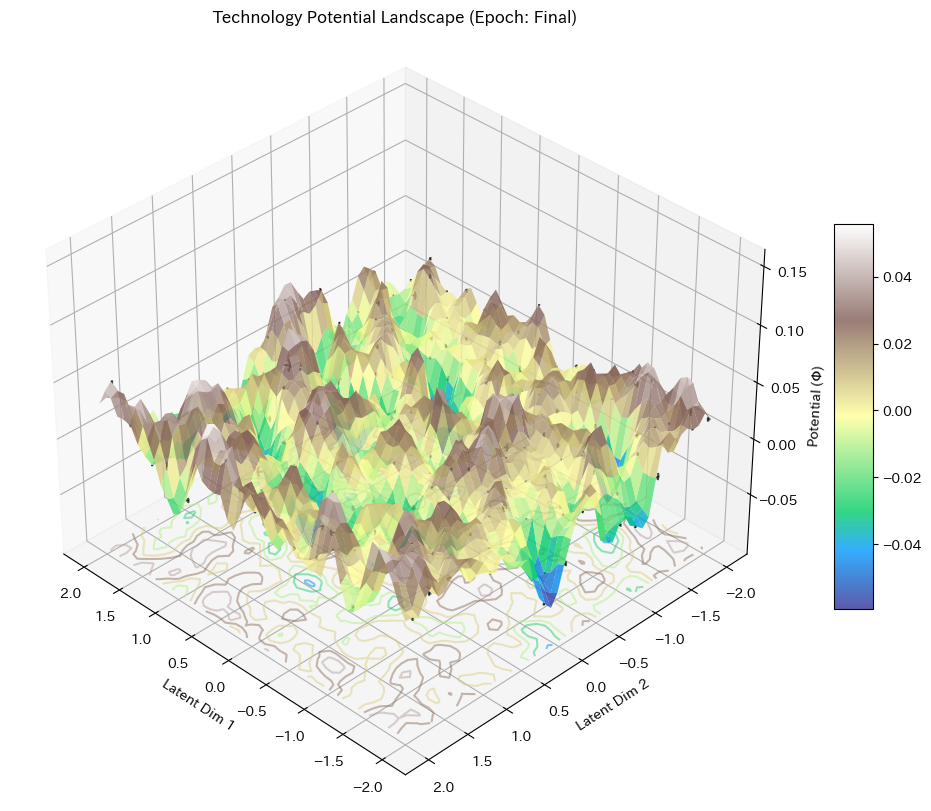

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def visualize_potential_landscape_3d(model, device, res=50, range_lim=2.0):
    """
    学習済みモデルのPotentialNetを3Dで可視化する
    """
    model.eval()
    potential_net = model.temporal_predictor.potential_net
    
    # 1. グリッドの生成 (潜在空間の座標軸)
    x = np.linspace(-range_lim, range_lim, res)
    y = np.linspace(-range_lim, range_lim, res)
    X, Y = np.meshgrid(x, y)
    
    # モデルが2次元入力(latent_dim=2)を期待している場合の処理
    grid_points = np.stack([X.flatten(), Y.flatten()], axis=1)
    grid_tensor = torch.tensor(grid_points, dtype=torch.float32).to(device)
    
    # 2. ポテンシャル Z の計算
    with torch.no_grad():
        # PotentialNetは (batch, latent_dim) を受け取って (batch, 1) を返す
        # latent_dim > 2 の場合は、残りの次元を0で埋める
        if model.latent_dim > 2:
            padding = torch.zeros(grid_tensor.shape[0], model.latent_dim - 2).to(device)
            grid_input = torch.cat([grid_tensor, padding], dim=-1)
        else:
            grid_input = grid_tensor
            
        Z = potential_net(grid_input).cpu().numpy().reshape(res, res)

    # 3. 勾配（ベクトル場）の計算
    # model.temporal_predictor.ode_func を利用して勾配を取得
    grid_tensor.requires_grad_(True)
    if model.latent_dim > 2:
        padding = torch.zeros(grid_tensor.shape[0], model.latent_dim - 2).to(device)
        grid_input_grad = torch.cat([grid_tensor, padding], dim=-1)
    else:
        grid_input_grad = grid_tensor
        
    phi = potential_net(grid_input_grad)
    grads = torch.autograd.grad(phi.sum(), grid_tensor)[0]
    
    # X, Y成分のみ抽出
    U = grads[:, 0].cpu().detach().numpy().reshape(res, res)
    V = grads[:, 1].cpu().detach().numpy().reshape(res, res)

    # 4. プロット
    fig = plt.figure(figsize=(14, 10))
    ax = fig.add_subplot(111, projection='3d')

    # A. 地形の描画
    surf = ax.plot_surface(X, Y, Z, cmap='terrain', alpha=0.8, 
                           edgecolor='none', antialiased=True)

    # B. 底面への投影
    offset = np.min(Z) - (np.max(Z) - np.min(Z)) * 0.2
    ax.contour(X, Y, Z, zdir='z', offset=offset, cmap='terrain', alpha=0.5)

    # C. 勾配ベクトルの表示 (Quiver)
    skip = 3
    ax.quiver(X[::skip, ::skip], Y[::skip, ::skip], Z[::skip, ::skip], 
              U[::skip, ::skip], V[::skip, ::skip], 0, 
              length=0.1, color='black', alpha=0.7)

    # 仕上げ
    ax.set_zlim(offset, np.max(Z) + 0.1)
    ax.set_xlabel("Latent Dim 1")
    ax.set_ylabel("Latent Dim 2")
    ax.set_zlabel("Potential ($\Phi$)")
    ax.set_title(f"Technology Potential Landscape (Epoch: Final)")
    fig.colorbar(surf, shrink=0.5, aspect=10)
    
    ax.view_init(elev=35, azim=135)
    plt.show()

# 実行例
visualize_potential_landscape_3d(trained_model_gradient_ode, device)

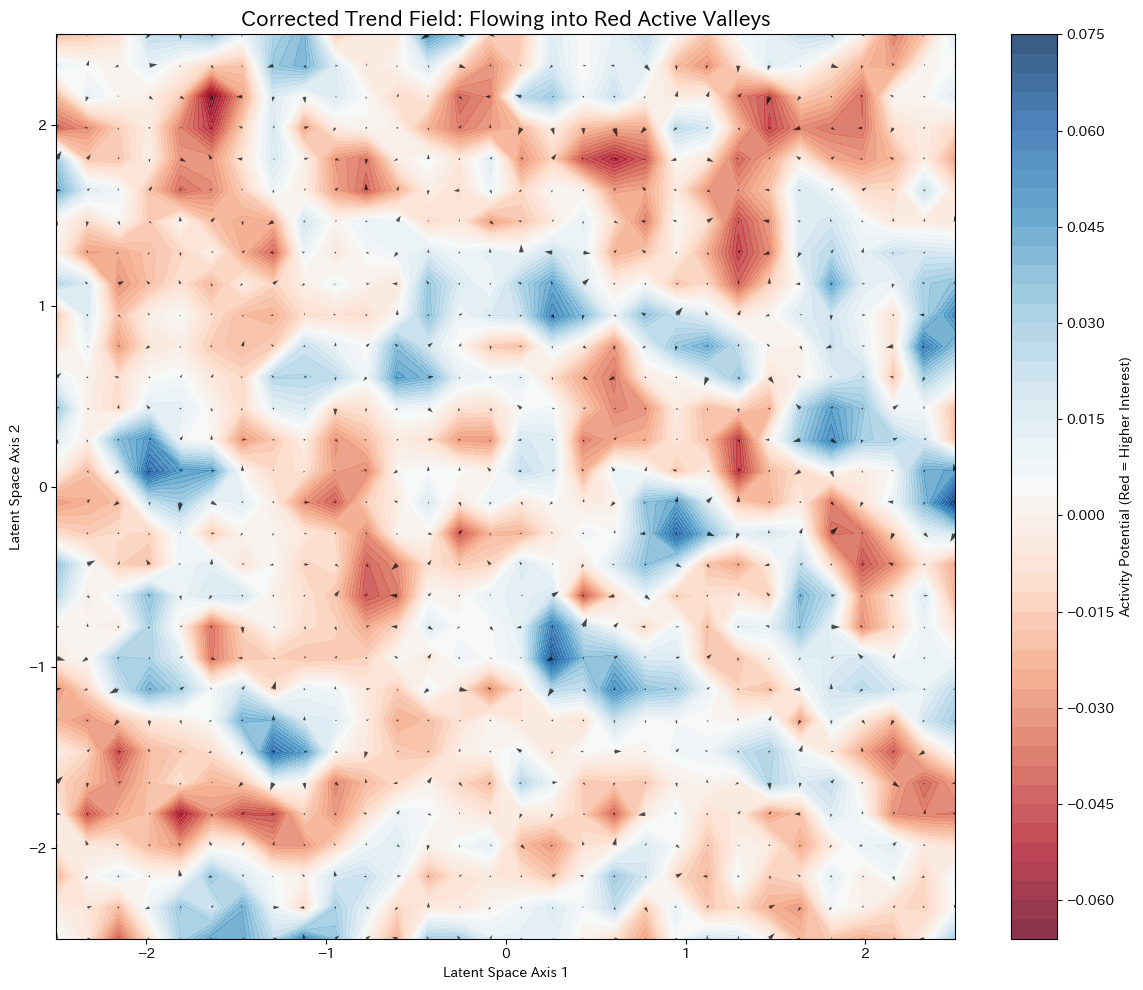

In [47]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def visualize_potential_vector_field_corrected(model, device, res=30, range_lim=2.5):
    model.eval()
    potential_net = model.temporal_predictor.potential_net
    
    # 1. グリッド生成
    x = np.linspace(-range_lim, range_lim, res)
    y = np.linspace(-range_lim, range_lim, res)
    X, Y = np.meshgrid(x, y)
    grid_points = np.stack([X.flatten(), Y.flatten()], axis=1)
    grid_tensor = torch.tensor(grid_points, dtype=torch.float32).to(device)
    
    if model.latent_dim > 2:
        padding = torch.zeros(grid_tensor.shape[0], model.latent_dim - 2).to(device)
        grid_input = torch.cat([grid_tensor, padding], dim=-1)
    else:
        grid_input = grid_tensor

    # 2. 計算
    grid_input.requires_grad_(True)
    phi = potential_net(grid_input)
    # 元の勾配（＝人気の中心を指すベクトル）を取得
    grads = torch.autograd.grad(phi.sum(), grid_input)[0]
    
    # 3. 反転のロジックを修正
    # 背景：マイナスにして「高い＝青、低い（谷）＝赤」にする
    Z_display = -phi.detach().cpu().numpy().reshape(res, res)
    
    # ベトル：元の grads をそのまま使う（＝元の山、つまり今の赤い谷へ向かう）
    U_display = grads[:, 0].detach().cpu().numpy().reshape(res, res)
    V_display = grads[:, 1].detach().cpu().numpy().reshape(res, res)

    # 4. プロット
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # 背景 (RdBu: Redが低、Blueが高)
    contour = ax.contourf(X, Y, Z_display, levels=50, cmap='RdBu', alpha=0.8)
    
    # ベクトル (Quiver)
    # 矢印が赤い「谷」に突き刺さるように見えるはずです
    Q = ax.quiver(X, Y, U_display, V_display, color='black', 
                  angles='xy', scale_units='xy', scale=10, # 見にくい場合はscaleを調整
                  width=0.002, alpha=0.7)
    
    ax.set_title("Corrected Trend Field: Flowing into Red Active Valleys", fontsize=15)
    ax.set_xlabel("Latent Space Axis 1")
    ax.set_ylabel("Latent Space Axis 2")
    fig.colorbar(contour, ax=ax, label='Activity Potential (Red = Higher Interest)')
    
    plt.tight_layout()
    plt.show()

visualize_potential_vector_field_corrected(trained_model_gradient_ode, device)

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def visualize_potential_streamline(model, device, res=100, range_lim=2.5):
    """
    流線（Streamline）を用いたトレンド可視化。
    - 赤（谷）: 技術が集中し、盛り上がっている領域
    - 青（山）: 廃れている、あるいは過疎化している領域
    - 流線: 技術が「次にどこへ吸い込まれていくか」の流れ
    """
    model.eval()
    potential_net = model.temporal_predictor.potential_net
    
    # 1. 高解像度のグリッド生成（流線を綺麗に出すために res=100 程度を推奨）
    x = np.linspace(-range_lim, range_lim, res)
    y = np.linspace(-range_lim, range_lim, res)
    X, Y = np.meshgrid(x, y)
    grid_points = np.stack([X.flatten(), Y.flatten()], axis=1)
    grid_tensor = torch.tensor(grid_points, dtype=torch.float32).to(device)
    
    if model.latent_dim > 2:
        padding = torch.zeros(grid_tensor.shape[0], model.latent_dim - 2).to(device)
        grid_input = torch.cat([grid_tensor, padding], dim=-1)
    else:
        grid_input = grid_tensor

    # 2. ポテンシャルと勾配の計算
    grid_input.requires_grad_(True)
    phi = potential_net(grid_input)
    # 元の勾配（＝高い方を目指す力）を抽出
    grads = torch.autograd.grad(phi.sum(), grid_input)[0]
    
    # 3. 表示用のデータ整形
    # 背景：マイナスをかけて「盛り上がり(高)=値が低い(赤/谷)」に変換
    Z_display = -phi.detach().cpu().numpy().reshape(res, res)
    
    # 速度場：元の勾配を使う（＝赤い谷底に向かう流れになる）
    U_display = grads[:, 0].detach().cpu().numpy().reshape(res, res)
    V_display = grads[:, 1].detach().cpu().numpy().reshape(res, res)

    # 4. プロット
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # 背景のカラーマップ (RdBu: Redが低、Blueが高)
    contour = ax.contourf(X, Y, Z_display, levels=50, cmap='RdBu', alpha=0.8)
    
    # 流線の表示 (Streamplot)
    # color='black' または '0.3'(濃いグレー)
    # density: 流線の密度, linewidth: 線の太さ
    stream = ax.streamplot(X, Y, U_display, V_display, 
                           color='black', linewidth=1.2, 
                           density=1.5, arrowsize=1.5, arrowstyle='->')
    
    # 5. 装飾
    ax.set_title("Future Technology Flow: Converging into Red Active Valleys", fontsize=15)
    ax.set_xlabel("Latent Space Axis 1")
    ax.set_ylabel("Latent Space Axis 2")
    
    # カラーバー
    cbar = fig.colorbar(contour, ax=ax)
    cbar.set_label('Activity Potential (Red: High Interest Valley)', rotation=270, labelpad=15)
    
    plt.tight_layout()
    plt.show()

# 実行
visualize_potential_streamline(trained_model_gradient_ode, device)

NameError: name 'trained_model_gradient_ode' is not defined